# 5.1 Plasma-cell-centered CellChat analysis

Author: Xuezhu Sunny Wang


## Dataset 📊

- Map the interaction between immune cells and plasma cells (amyloid/polyclonal)

## Steps overview 📒

- Assign the cell types to the bone marrow microenvironment cells (from )

## Important note ⚠️
- Multiple trials have been done for this analysis. Needs further cleaning up before publication.

In [1]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DoubletFinder)
library(SoupX)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t






Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollaps

In [2]:
sce1<-readRDS(file='./250817-AL-all78umap-singletonly-umap.rds')

Assign the cell type annotation for each lineage to the bone marrow microenvironment cells.

In [3]:
library(tidyverse)

# --- Read ---
label1 <- readr::read_csv("TME.noverlabel.csv", show_col_types = FALSE)
label2 <- readr::read_csv("PC.noverlabel.csv", show_col_types = FALSE)
label3 <- readr::read_csv("Tcell.noverlabel.csv", show_col_types = FALSE)
label4 <- readr::read_csv("Bcell.noverlabel.csv", show_col_types = FALSE)
label5 <- readr::read_csv("Mono.noverlabel.csv", show_col_types = FALSE)
label6 <- readr::read_csv("NKcell.noverlabel.csv", show_col_types = FALSE)

# --- Helper: unify names & types ---
normalize <- function(df) {
  df %>%
    rename(
      barcode = any_of(c("barcode","Barcode")),  # handles the 'barocde' typo
      Nover   = any_of(c("Nover","Annotation","celltype","final_label","clonotype"))
    ) %>%
    mutate(
      barcode = as.character(barcode),
      # make Nover numeric; non-numeric becomes NA (prevents bind_rows() type clash)
      Nover   = as.character(Nover)
    ) %>%
    select( barcode, Nover)
}

label1 <- normalize(label1)
label2 <- normalize(label2)
label3 <- normalize(label3)
label4 <- normalize(label4)
label5 <- normalize(label5)
label6 <- normalize(label6)

# --- Build replacement lookups from label3–6 ---
lookup <- bind_rows(
  mutate(label2, .src = "Plasmacell"),
  mutate(label3, .src = "Tcell"),
  mutate(label4, .src = "Bcell"),
  mutate(label5, .src = "Mono"),
  mutate(label6, .src = "NKcell")
) %>%
  # priority order
  arrange(factor(.src, levels = c( "Plasmacell","Tcell","Bcell","Mono","NKcell"))) %>%
  group_by(barcode) %>%
  summarise(Nover_new = first(na.omit(Nover)), .groups = "drop")

# --- Replace Nover in label1 using the lookup (by barcode) ---
label1_updated <- label1 %>%
  left_join(lookup, by = "barcode") %>%
  mutate(Nover = coalesce(Nover_new, Nover)) %>%
  select(barcode, Nover)

# --- Bind label2 on it ---
final_tbl <- unique(bind_rows(label1_updated, label2))

# (optional) save
# write_csv(final_tbl, "combined_noverlabel.csv")

final_tbl


Warning message:
“‘timedatectl’ indicates the non-existent timezone name ‘n/a’”
Warning message:
“Your system is mis-configured: ‘/etc/localtime’ is not a symlink”
Warning message:
“It is strongly recommended to set envionment variable TZ to ‘Etc/UCT’ (or equivalent)”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%()    masks IRanges::%within%()
✖ dplyr::collapse()        masks IRanges::collapse()
✖ dplyr::combine()         masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::count()           masks matrixStats::count()
✖ dplyr::desc()            masks IRanges::desc()
✖ tidyr::expand()          masks Matrix::expand(), S4Vectors::expand()
✖ dplyr::filter()          masks stats::filter()
✖ d

barcode,Nover
<chr>,<chr>
ALl14_AAACCCAGTTAAACCC-1,CD4_CM
ALl14_AAACCCATCGTCCTTG-1,Erythroid_CD34- CD71+ GlyA+
ALl14_AAACCCATCTCATTAC-1,CD14 Mono_set1High_set2High
ALl14_AAACCCATCTGTAACG-1,CD4_CM
ALl14_AAACGAAAGACCCTTA-1,CD14 Mono_set1High_set2High
ALl14_AAACGAAAGTAACCGG-1,Granulocytes (Neutrophils)
ALl14_AAACGAAAGTGATAGT-1,CD4_EM
ALl14_AAACGAACAGAAATCA-1,Colony Forming Unit-Monocytes
ALl14_AAACGAACATAGAGGC-1,CD14 Mono_set1Low_set2High


In [4]:
rownames(final_tbl)<-final_tbl$barcode
sce1@meta.data<-cbind(sce1@meta.data,final_tbl[rownames(sce1@meta.data),])

Warning message:
“Setting row names on a tibble is deprecated.”


scCustomize v2.1.2
If you find the scCustomize useful please cite.
See 'samuel-marsh.github.io/scCustomize/articles/FAQ.html' for citation info.



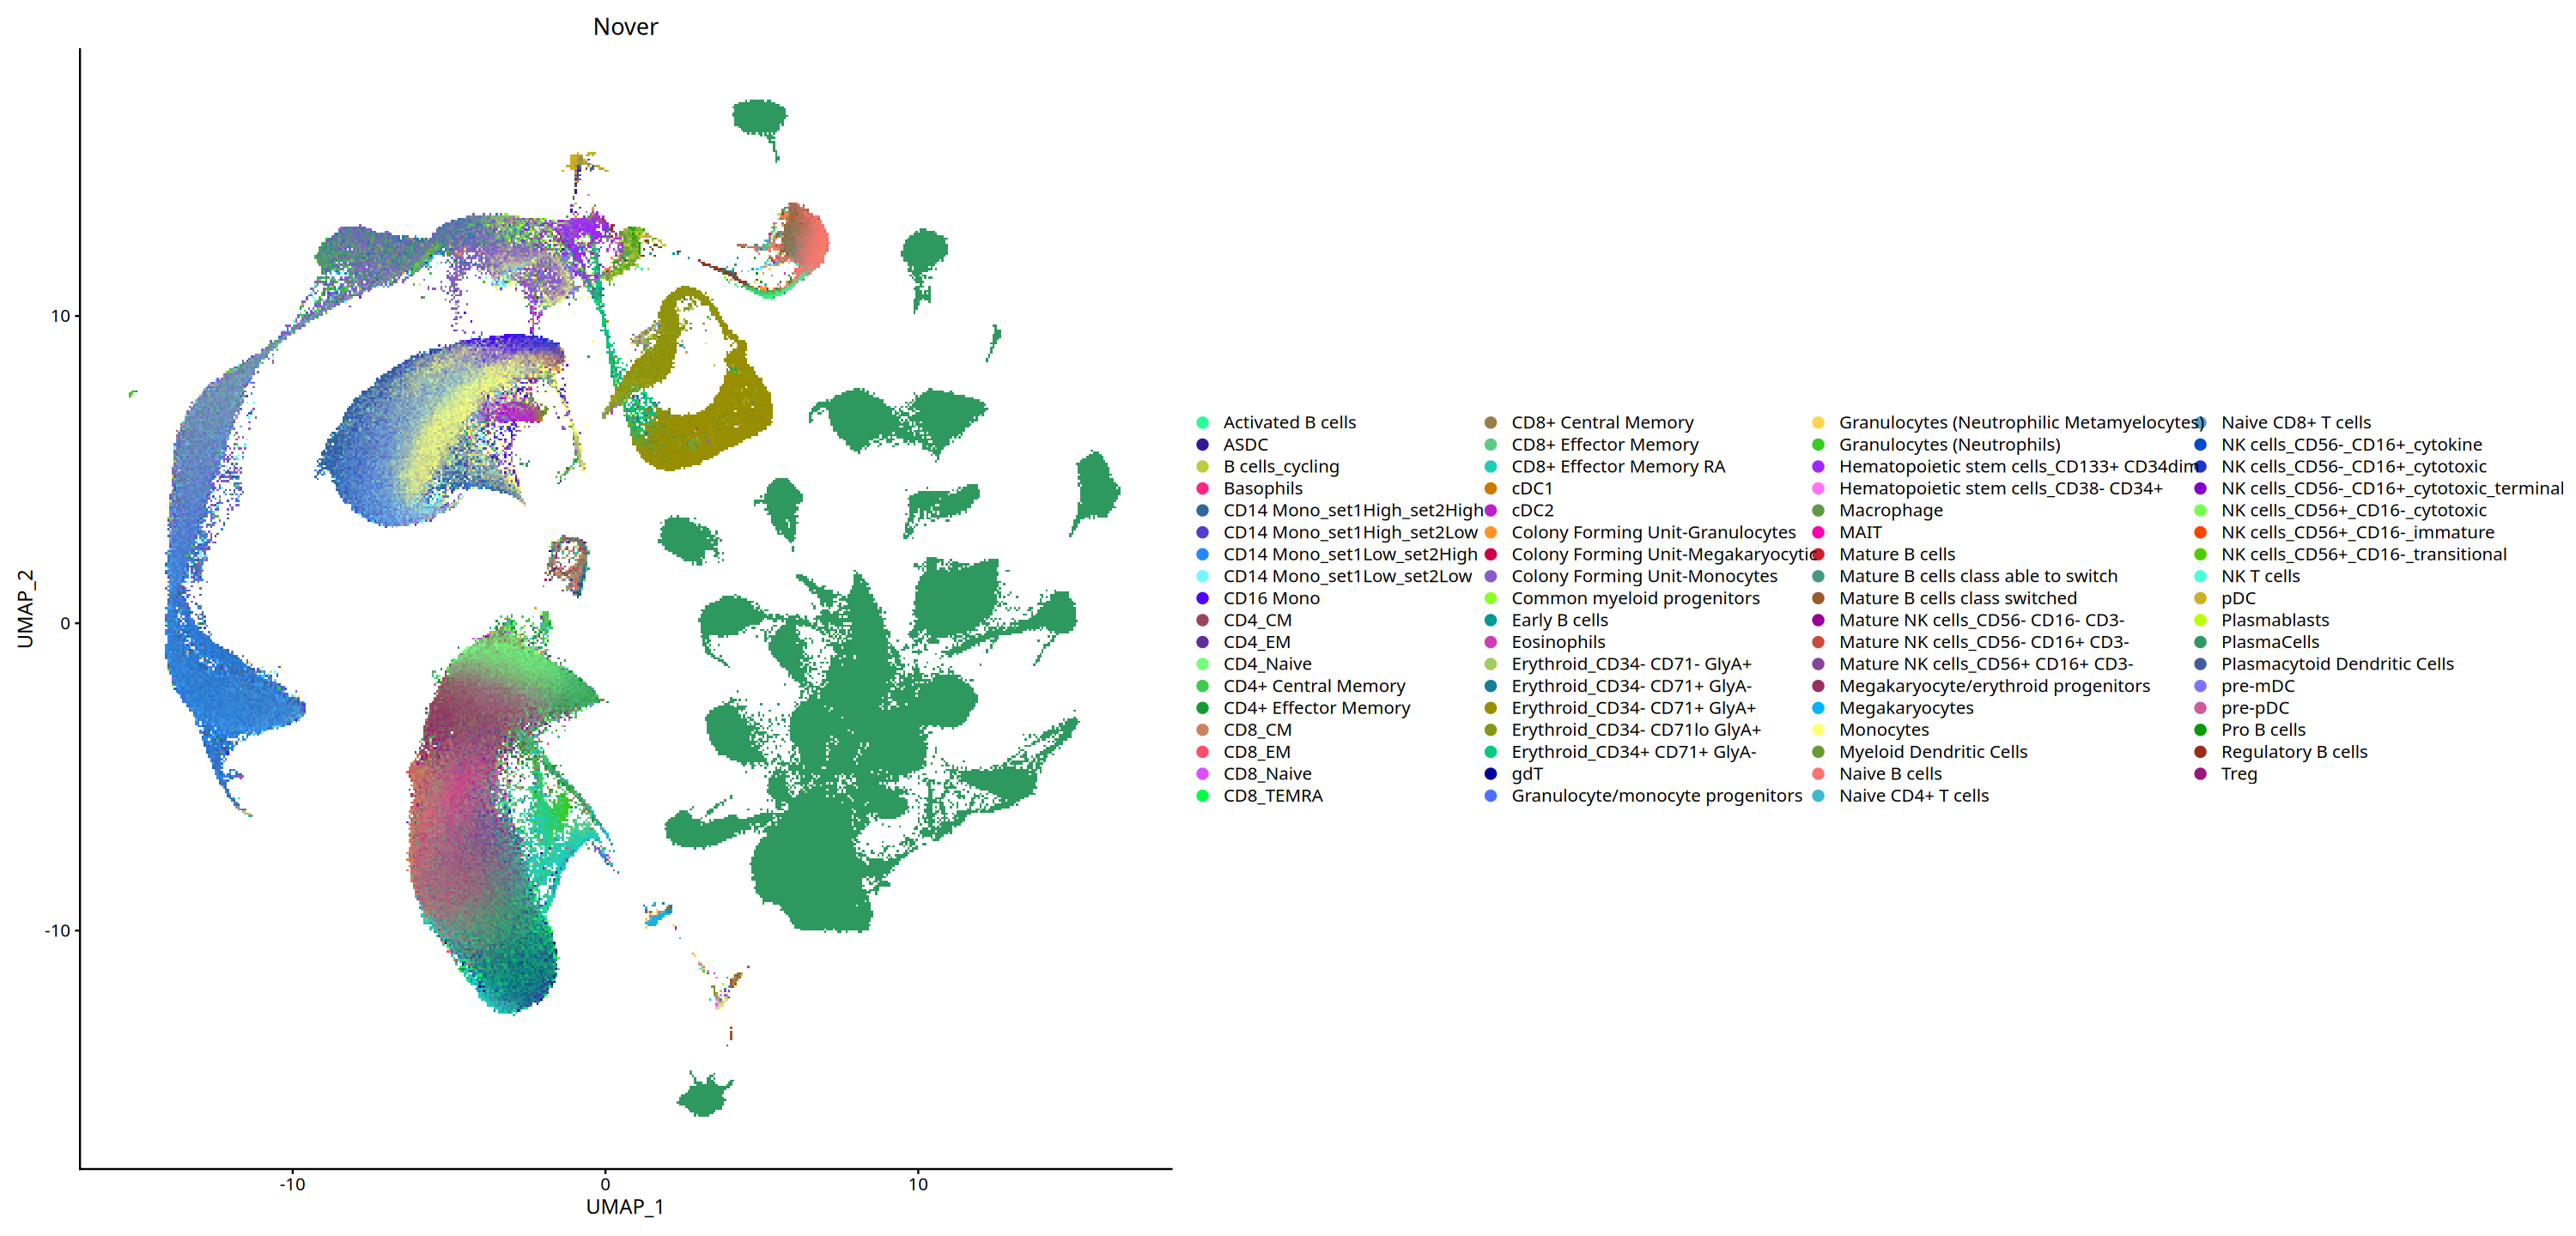

In [5]:
library(scCustomize)
options(repr.plot.height=12,repr.plot.width=25)
DimPlot_scCustom(sce1, pt.size=1,reduction = "UMAP", group.by = c("Nover"),label=F) 

In [6]:
sce1

An object of class Seurat 
36601 features across 630111 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, UMAP

In [7]:
# First: optional example filter you had for 'plasma' in orig.ident
cells_to_keep <- rownames(sce1@meta.data)[!grepl("plasma", sce1@meta.data$orig.ident)]
sce1 <- subset(sce1, cells = cells_to_keep)

# Keywords to exclude (substring match, case-insensitive) EXCEPT "Mature B cells" which is exact only
keywords_sub <- c("Central","Effector","Mature NK cells_CD56-",
                  "Mature NK cells_CD56+","Monocytes",
                  "Naive CD8+ T cells","Naive CD4+ T cells")

# Build regex for substring keywords (escape specials)
rx_sub <- paste(paste0("\\Q", keywords_sub, "\\E"), collapse = "|")

# Column to check
v <- as.character(sce1@meta.data$Nover)

# 1) Exact match mask for just "Mature B cells"
m_exact_matureB <- tolower(trimws(v)) == "mature b cells"

# 2) Substring mask for the other keywords
m_sub <- grepl(rx_sub, v, ignore.case = TRUE, perl = TRUE)
m_sub[is.na(m_sub)] <- FALSE

# Combine: drop exact "Mature B cells" OR any substring match from keywords_sub
m_drop <- (m_exact_matureB %in% TRUE) | m_sub

cells_to_keep <- rownames(sce1@meta.data)[!m_drop]
sce1 <- subset(sce1, cells = cells_to_keep)


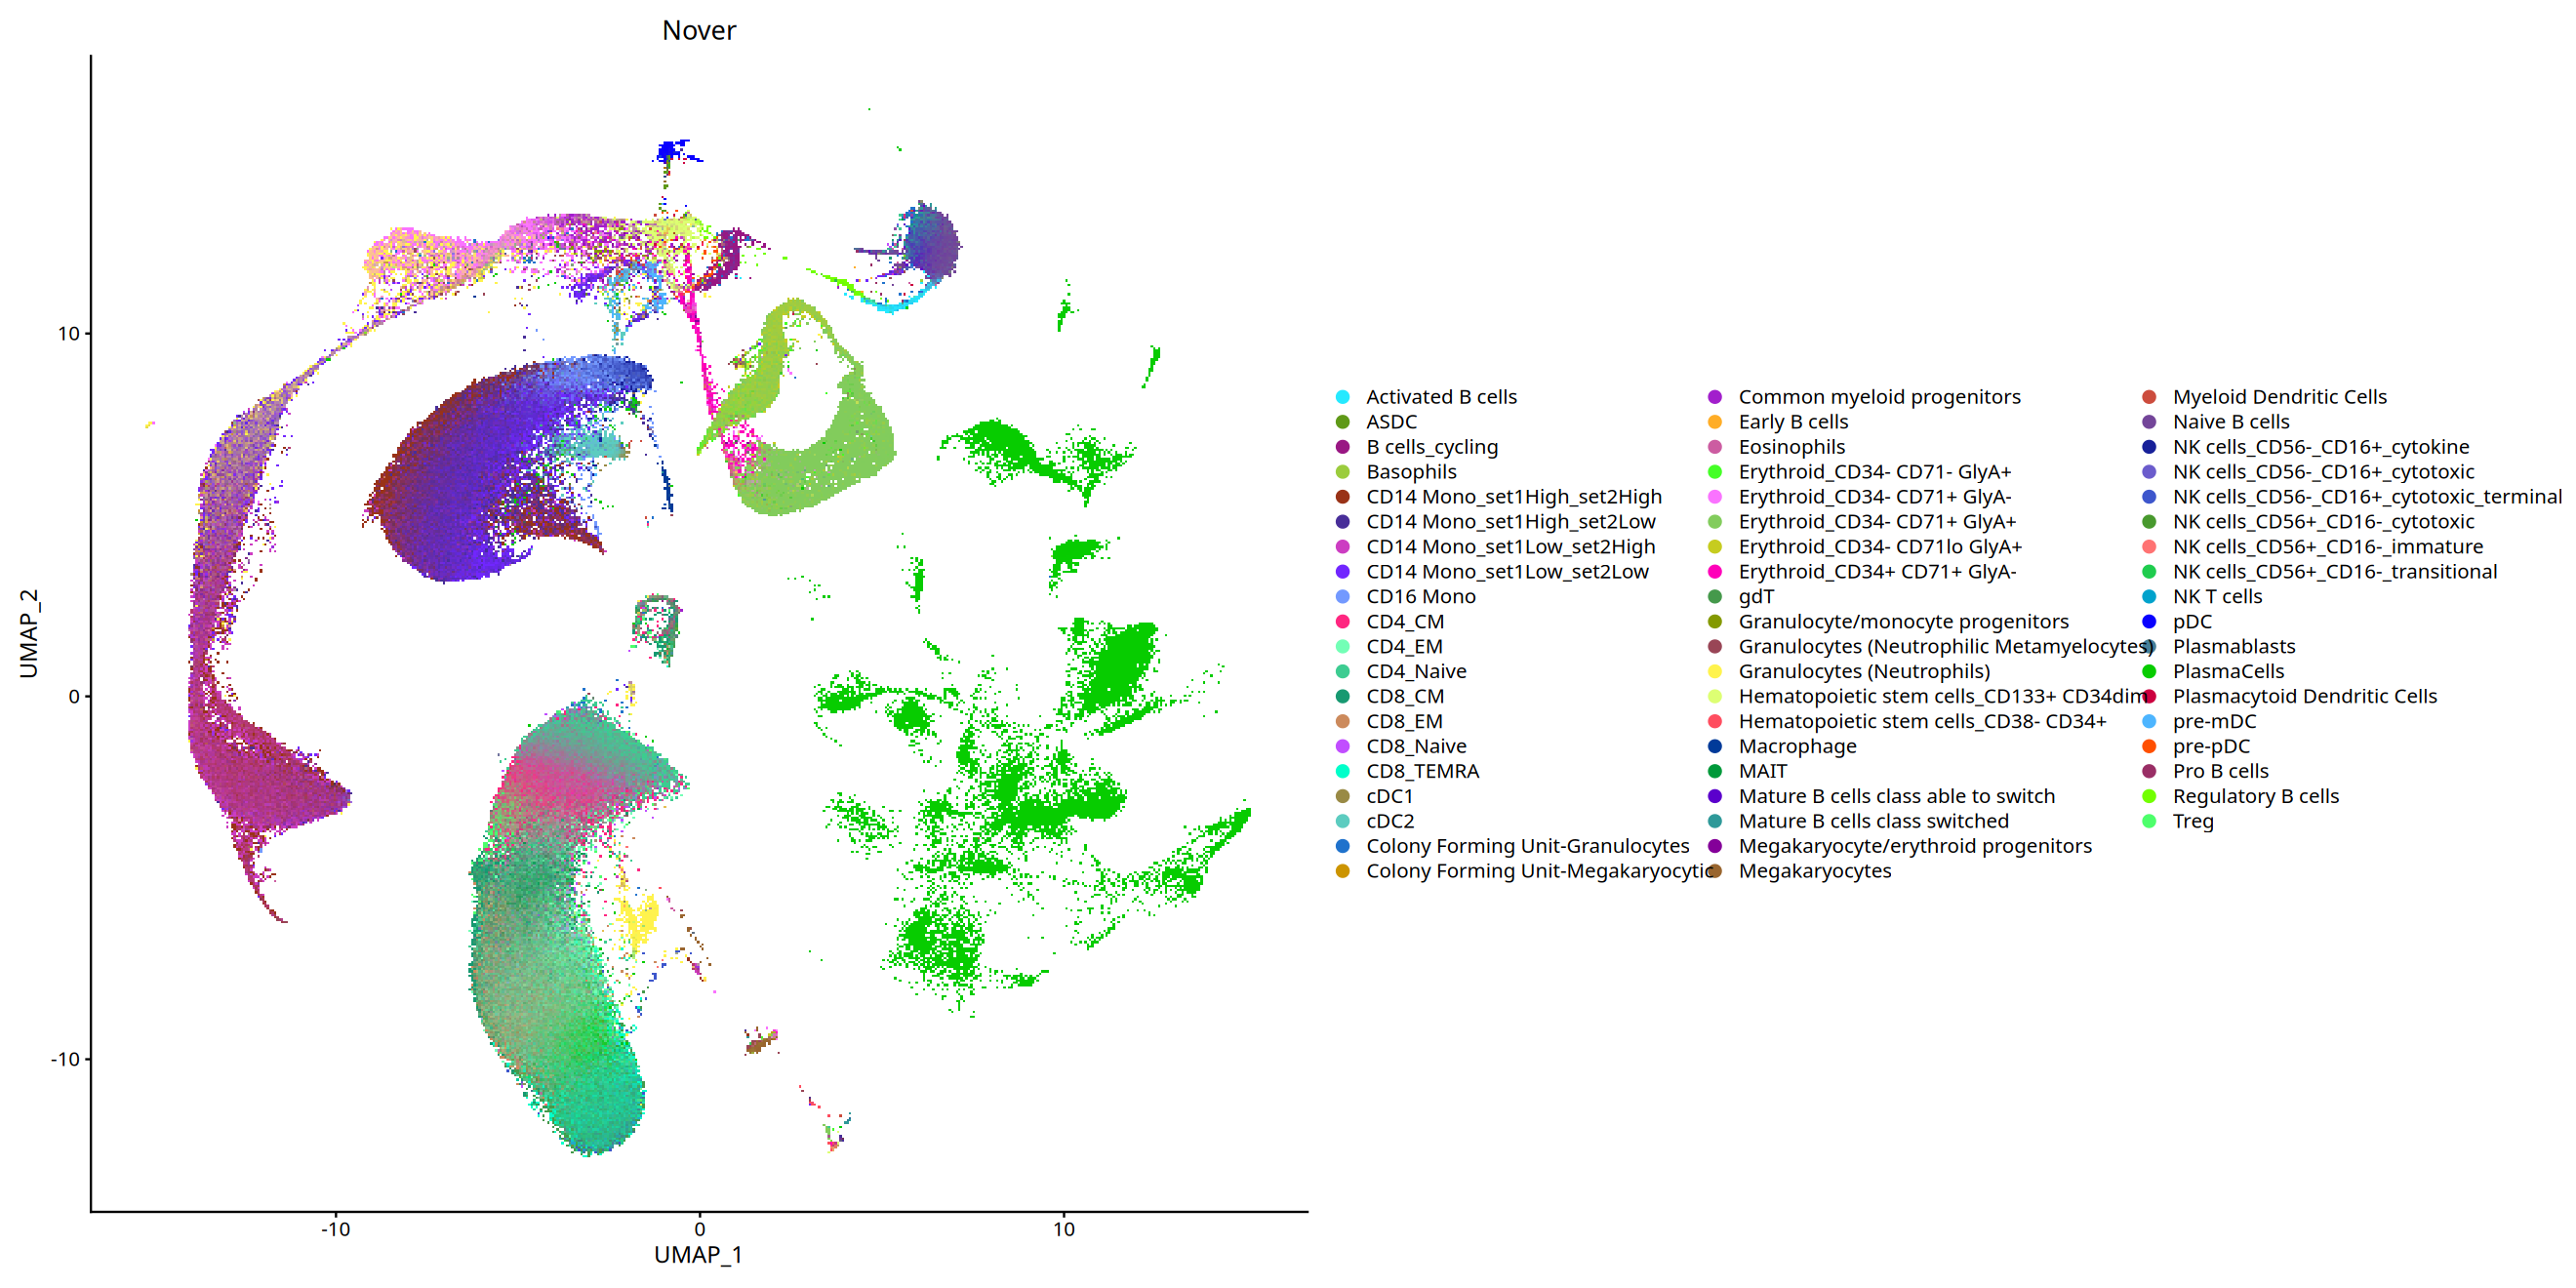

In [8]:
library(scCustomize)
options(repr.plot.height=11,repr.plot.width=22)
DimPlot_scCustom(sce1, pt.size=1,reduction = "UMAP", group.by = c("Nover"),label=F) 

In [9]:
sce1

An object of class Seurat 
36601 features across 322192 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, UMAP

In [10]:
p <- DimPlot_scCustom(sce1, pt.size=1,reduction = "UMAP", group.by = c("Nover"),label=F) 
ggsave("Fig4a.pdf", plot = p, width = 22, height =11)


In [11]:
library(ggplot2)

# Robust color extractor for a DimPlot/ggplot made by scCustomize
extract_dimplot_colors <- function(p, group_col = "ident") {
  # 1) Try to pull a discrete colour or fill scale with explicit values
  get_scale_vals <- function(p, aes_name) {
    sc <- p$scales$get_scales(aes_name)
    if (!is.null(sc)) {
      vals <- tryCatch(sc$range$range, error = function(e) NULL)
      lims <- tryCatch(sc$get_limits(), error = function(e) NULL)
      if (!is.null(vals) && length(vals) > 0) {
        # If limits missing, infer from legend/plot data levels
        if (is.null(lims) || length(lims) == 0) {
          # Try to use factor levels from p$data[[group_col]] if present
          if (!is.null(p$data[[group_col]])) {
            lims <- levels(factor(p$data[[group_col]]))
          } else {
            lims <- seq_along(vals)
          }
        }
        # If lengths differ, truncate to the shorter length safely
        n <- min(length(vals), length(lims))
        vals <- vals[seq_len(n)]
        lims <- lims[seq_len(n)]
        return(setNames(vals, lims))
      }
    }
    NULL
  }

  cols <- get_scale_vals(p, "colour")
  if (is.null(cols)) cols <- get_scale_vals(p, "color")
  if (is.null(cols)) cols <- get_scale_vals(p, "fill")

  # 2) Fallback: use rendered point colors from ggplot_build() and map back to groups
  if (is.null(cols)) {
    pb <- ggplot_build(p)
    if (length(pb$data) == 0) stop("Plot has no layer data; cannot extract colors.")
    d_layer <- pb$data[[1]]

    # Guess the grouping column used by DimPlot_scCustom
    # Seurat/DimPlot usually stores grouping in p$data$ident when group.by is a single column.
    if (is.null(p$data[[group_col]])) {
      # If 'ident' missing, try common alternatives (including your 'Nover')
      for (cand in c("ident", "group", "Nover")) {
        if (!is.null(p$data[[cand]])) { group_col <- cand; break }
      }
    }
    if (is.null(p$data[[group_col]])) {
      stop("Could not find a grouping column on the plot data (tried: ident, group, Nover).")
    }

    # Build mapping by row alignment (DimPlot preserves row order)
    df_map <- data.frame(
      group = as.character(p$data[[group_col]]),
      colour = d_layer$colour,
      stringsAsFactors = FALSE
    )

    # Keep first color per group (legend color)
    df_map <- df_map[!duplicated(df_map$group), ]
    cols <- setNames(df_map$colour, df_map$group)
  }

  cols
}


As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.
Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.


pdf 
  2

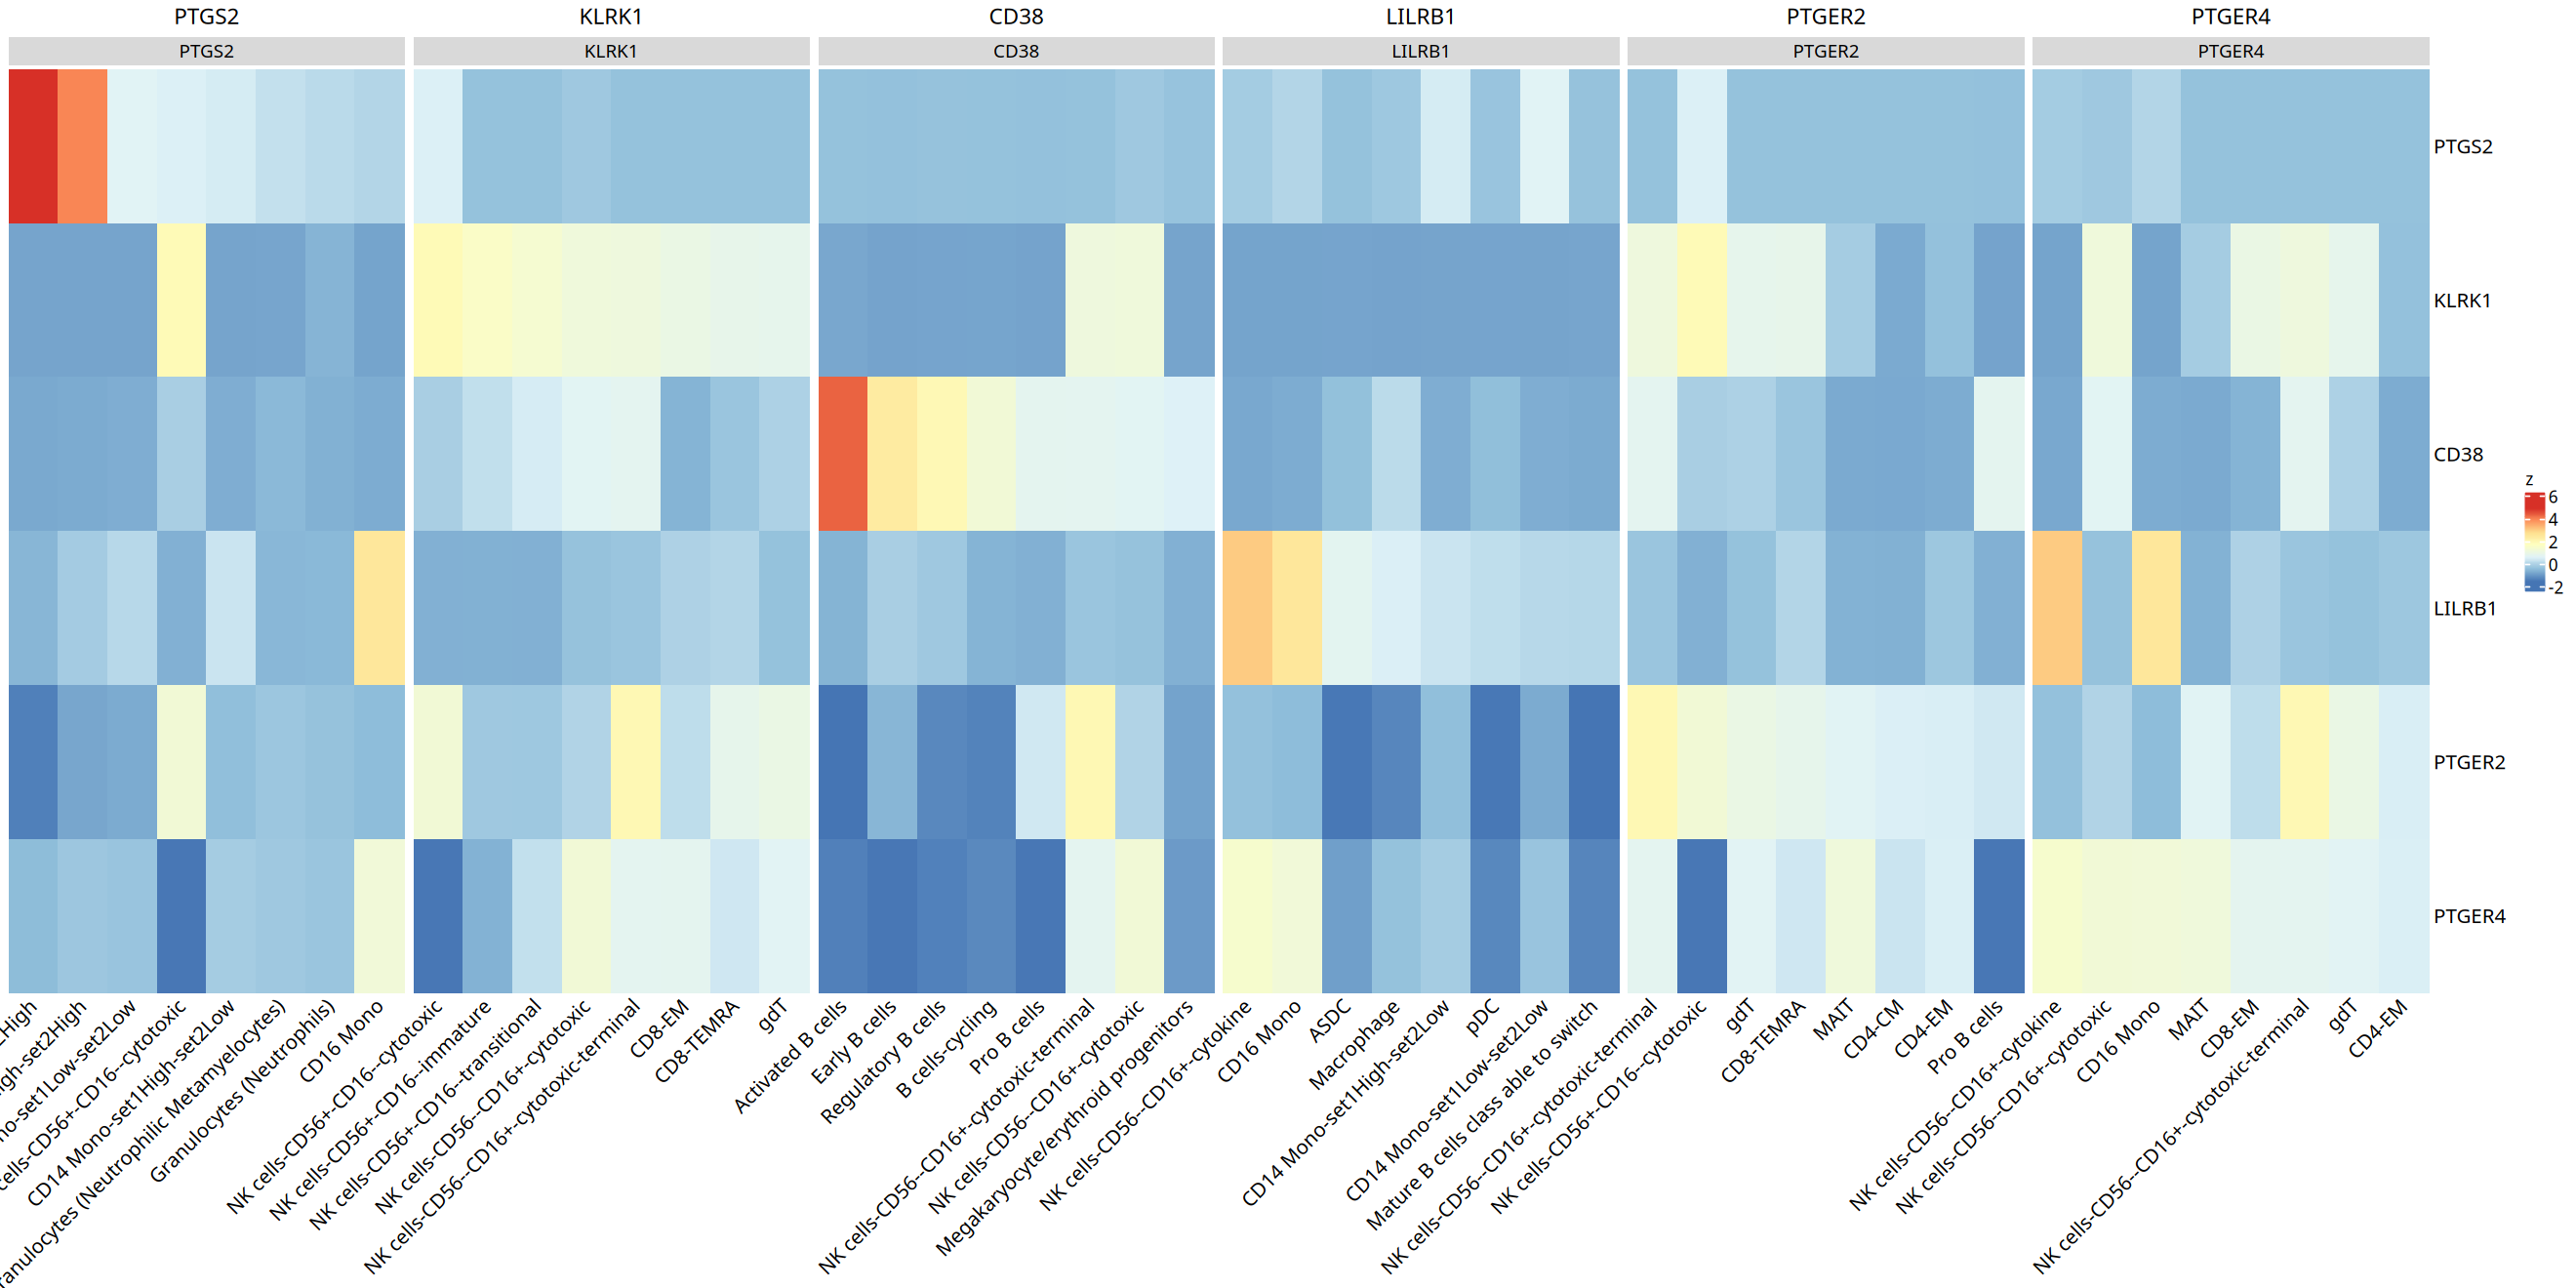

In [12]:
suppressPackageStartupMessages({
  library(Seurat)
  library(dplyr)
  library(tibble)
  library(tidyr)
})

# ---- required for gene "tags" with text inside ----
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(circlize)
  library(grid)
  library(RColorBrewer)
})

# ---------------------------
# 0) Inputs
# ---------------------------
genes_use <- c("CD38","KLRK1","LILRB1","PTGS2","PTGER2","PTGER4")
group_col <- "Nover"
top_n <- 8

assay_use <- DefaultAssay(sce1)
slot_use  <- "data"   # normalized log; change to "counts" if needed

# ---------------------------
# 1) Average expression: genes x cell types
# ---------------------------
avg_list <- AverageExpression(
  sce1,
  assays   = assay_use,
  features = genes_use,
  group.by = group_col,
  slot     = slot_use,
  verbose  = FALSE
)

avg_mat <- avg_list[[assay_use]]
avg_mat <- avg_mat[intersect(rownames(avg_mat), genes_use), , drop = FALSE]

# ---------------------------
# 2) Long table + top-N per gene (NO de-dup)
# ---------------------------
expr_long <- as.data.frame(avg_mat) %>%
  rownames_to_column("gene") %>%
  pivot_longer(-gene, names_to = "cell_type", values_to = "mean_expr") %>%
  group_by(gene) %>%
  arrange(desc(mean_expr), .by_group = TRUE) %>%
  mutate(rank_in_gene = row_number()) %>%
  filter(rank_in_gene <= top_n) %>%
  ungroup()

# ---------------------------
# 3) Waterfall ordering without de-dup
# ---------------------------
gene_order <- expr_long %>%
  group_by(gene) %>%
  summarise(top_expr = max(mean_expr, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(top_expr), gene) %>%
  pull(gene)

expr_long <- expr_long %>%
  mutate(gene = factor(gene, levels = gene_order)) %>%
  arrange(gene, desc(mean_expr), rank_in_gene)

expr_long <- expr_long %>%
  group_by(gene) %>%
  mutate(block_pos = row_number()) %>%
  ungroup() %>%
  mutate(col_id = paste0(cell_type, "__", as.character(gene)))  # unique per block

col_map <- expr_long %>%
  select(col_id, cell_type, gene, mean_expr, rank_in_gene, block_pos)

col_order <- col_map$col_id

# ---------------------------
# 4) Build matrix showing ALL genes' expression for displayed columns
# ---------------------------
hm_full <- matrix(NA_real_,
                  nrow = nrow(avg_mat),
                  ncol = nrow(col_map),
                  dimnames = list(rownames(avg_mat), col_map$col_id))

for (j in seq_len(nrow(col_map))) {
  ct <- col_map$cell_type[j]
  hm_full[, j] <- avg_mat[, ct]
}

# Row-scale across displayed columns
scale_rows_full <- function(m) {
  z <- t(scale(t(m)))
  z[is.nan(z)] <- 0
  z
}
hm_full_z <- scale_rows_full(hm_full)

# Order rows/cols
hm_full_z <- hm_full_z[gene_order, col_order, drop = FALSE]

# ---------------------------
# 5) Gene "tags" (grey blocks with gene name inside) + plot
# ---------------------------
# column split factor defines the blocks
col_split <- factor(as.character(col_map$gene), levels = gene_order)

# top annotation: grey tag per block with the gene name centered
top_anno <- HeatmapAnnotation(
  Gene = anno_block(
    gp = gpar(fill = "grey85", col = NA),
    labels = levels(col_split),
    labels_gp = gpar(col = "black", fontsize = 10, fontface = "bold")
  ),
  show_annotation_name = FALSE
)

# heatmap color function (pheatmap-like diverging palette)
pal <- colorRampPalette(rev(brewer.pal(7, "RdYlBu")))(101)
rng <- range(hm_full_z, finite = TRUE)
col_fun <- circlize::colorRamp2(
  seq(rng[1], rng[2], length.out = length(pal)),
  pal
)

ht <- Heatmap(
  hm_full_z,
  name = "z",
  col = col_fun,
  cluster_rows = FALSE,
  cluster_columns = FALSE,

  # waterfall layout
  column_split = col_split,
  column_gap = unit(2, "mm"),

  # labels
  show_row_names = TRUE,
  row_names_side = "left",
  show_column_names = TRUE,
  column_labels = col_map$cell_type,   # repeats allowed
  column_names_rot = 45,

  # gene tags
  top_annotation = top_anno
)

# Jupyter sizing hint (ComplexHeatmap uses grid; sizing is controlled by device)
draw(ht, heatmap_legend_side = "right", annotation_legend_side = "right")

# ---------------------------
# 6) Save
# ---------------------------
write.csv(col_map, "Top_celltypes_per_gene_NO_dedup.csv", row.names = FALSE)

pdf("Heatmap_waterfall_NO_dedup_FULL_geneTagsGrey.pdf", width = 18, height = 5)
draw(ht, heatmap_legend_side = "right", annotation_legend_side = "right")
dev.off()


# ---- requires these packages ----
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  library(circlize)
  library(grid)
  library(RColorBrewer)
})

# column blocks = gene that generated this block (from col_map)
col_split <- factor(as.character(col_map$gene), levels = gene_order)

# Grey "tag" with gene name INSIDE (one label per block)
top_anno <- HeatmapAnnotation(
  GeneTag = anno_block(
    gp = gpar(fill = "grey85", col = NA),                 # grey tag background
    labels = levels(col_split),                           # gene names (once per block)
    labels_gp = gpar(col = "black", fontsize = 11, fontface = "bold")
  ),
  show_annotation_name = FALSE,
  annotation_height = unit(6, "mm")                      # tag thickness (adjust)
)

# Heatmap color mapping
pal <- colorRampPalette(rev(brewer.pal(7, "RdYlBu")))(101)
rng <- range(hm_full_z, finite = TRUE)
col_fun <- circlize::colorRamp2(
  seq(rng[1], rng[2], length.out = length(pal)),
  pal
)

ht <- Heatmap(
  hm_full_z,
  name = "z",
  col = col_fun,
  cluster_rows = FALSE,
  cluster_columns = FALSE,

  # Waterfall blocks + spacing
  column_split = col_split,
  column_gap = unit(2, "mm"),

  # Put the gene-name "tags" on top
  top_annotation = top_anno,

  # Labels
  show_row_names = TRUE,
  show_column_names = TRUE,
  column_labels = col_map$cell_type,   # keep cell type labels (repeats allowed)
  column_names_rot = 45
)

draw(ht, heatmap_legend_side = "right")



In [16]:
#### cellchat_per_sample_from_seurat.R
# Computes CellChat per sample (orig.ident), filters pathways that involve plasma cells,
# ranks by prob, and reports immune partners + LR pairs.
# -----------------------------------------------------------------------------

suppressPackageStartupMessages({
  library(Seurat)
  library(CellChat)
  library(Matrix)
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(purrr)
  library(readr)
})

# ------------------------------ USER SETTINGS --------------------------------
# REQUIRED: your Seurat object (change variable name if needed)
seu <- get("sce1", envir = .GlobalEnv)   # <-- or replace "all" with your object name

# Column with cell types used as CellChat "group"
group_col   <- "Nover"             # e.g., "Nover" (or "celltype", etc.)

# Column with sample IDs to iterate over
sample_col  <- "orig.ident"

# Species for CellChat DB: "mouse" or "human"
species     <- "human"

# CellChat thresholds
expr_prop   <- 0.05     # % expressed threshold for identifyOverExpressedGenes (0-1)
min_cells   <- 10       # minimum cells per group for filterCommunication

# Optional output directory (NULL = don't write to disk)
out_dir <- "./cellchat_per_sample_plasma_trial3_repeat_repeat/"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)
write_outputs <- TRUE  # set FALSE if you don’t want CSVs

# Number of top pathways to keep per sample in summary (you still get full details CSV)
top_k_pathways <- 20
# -----------------------------------------------------------------------------


# ------------------------- Helper: robust compute -----------------------------
.try_compute <- function(cc) {
  ok <- TRUE
  cc2 <- tryCatch({
    computeCommunProb(cc, raw.use = TRUE, type = "truncatedMean", trim = 0.1)
  }, error = function(e) { ok <<- FALSE; e })
  if (ok) return(cc2)

  ok <- TRUE
  cc2 <- tryCatch({
    computeCommunProb(cc, raw.use = TRUE, type = "triMean")
  }, error = function(e) { ok <<- FALSE; e })
  if (ok) return(cc2)

  ok <- TRUE
  cc2 <- tryCatch({
    computeCommunProb(cc, raw.use = FALSE, type = "truncatedMean", trim = 0.1)
  }, error = function(e) { ok <<- FALSE; e })
  if (ok) return(cc2)

  stop("computeCommunProb failed under multiple settings; data may have no valid LR after filtering.")
}

# ------------------------- Helper: one-sample run -----------------------------
run_cellchat_for_subset <- function(seu_sub, group_col, species, expr_prop = 0.05, min_cells = 10) {
  # Get counts as genes x cells (CellChat expects that orientation)
  counts <- tryCatch(
    {
      # Seurat v5: use 'layer'; v4: slot="counts"
      GetAssayData(seu_sub, slot = "counts")  # works v4+ (deprecation warning in v5 is fine)
    },
    error = function(e) {
      # fallback to data slot if counts missing
      GetAssayData(seu_sub, slot = "data")
    }
  )
  if (!inherits(counts, "dgCMatrix")) counts <- as(as.matrix(counts), "dgCMatrix")

  # Build meta with "group" column (cell type)
  meta <- seu_sub@meta.data
  meta$cell  <- colnames(seu_sub)
  if (!group_col %in% colnames(meta)) {
    stop(sprintf("group_col '%s' not found in meta.data. Available: %s",
                 group_col, paste(colnames(meta), collapse = ", ")))
  }
  meta$group <- as.character(meta[[group_col]])
  rownames(meta) <- meta$cell
  meta <- meta[colnames(counts), c("cell", "group"), drop = FALSE]

  # Choose DB
  if (tolower(species) == "mouse") {
    data.cellchat <- CellChatDB.mouse
  } else {
    data.cellchat <- CellChatDB.human
  }

  # Create & subset to signaling genes
  cellchat <- createCellChat(object = counts, meta = meta, group.by = "group")
  cellchat@DB <- data.cellchat
  cellchat <- subsetData(cellchat)

  # Over-expressed genes/interactions
  expr_prop <- max(0.0, min(1.0, expr_prop))
  cellchat <- identifyOverExpressedGenes(cellchat, thresh.pc = expr_prop)
  cellchat <- identifyOverExpressedInteractions(cellchat)

  # Retry with more lenient threshold if no LR left
  if (!is.null(cellchat@LR$LRsig) && nrow(cellchat@LR$LRsig) == 0) {
    message("No LR after OE-filter; retrying with thresh.pc=0")
    cellchat <- identifyOverExpressedGenes(cellchat, thresh.pc = 0)
    cellchat <- identifyOverExpressedInteractions(cellchat)
  }

  # Compute communication probabilities
  cellchat <- .try_compute(cellchat)

  # Enforce min cells per group for robustness
  cellchat <- filterCommunication(cellchat, min.cells = min_cells)

  # Extract pairwise communication table
  df.net <- subsetCommunication(cellchat)

  # Standardize prob column name if needed
  if (!"prob" %in% colnames(df.net)) {
    if ("prob_weight" %in% colnames(df.net)) {
      df.net$prob <- df.net$prob_weight
    } else if ("weight" %in% colnames(df.net)) {
      df.net$prob <- df.net$weight
    }
  }

  df.net
}

# --------------------------- Main per-sample loop -----------------------------
all_samples <- sort(unique(seu[[sample_col]][,1]))
message(sprintf("Found %d samples via %s", length(all_samples), sample_col))

results_list <- list()

for (sid in all_samples) {
  message(sprintf(">>> Processing sample: %s", sid))
  seu_sub <- subset(seu, subset = !!as.name(sample_col) == sid)

  # Quick guard: require at least two groups and enough cells
  tab_groups <- table(seu_sub@meta.data[[group_col]])
  if (length(tab_groups) < 2) {
    message(sprintf("Skipping %s: <2 groups in '%s'", sid, group_col))
    next
  }

  df.net <- tryCatch(
    run_cellchat_for_subset(seu_sub, group_col, species, expr_prop, min_cells),
    error = function(e) {
      message(sprintf("CellChat failed for %s: %s", sid, e$message))
      NULL
    }
  )
  if (is.null(df.net) || nrow(df.net) == 0) {
    message(sprintf("No interactions for %s after filtering.", sid))
    next
  }

  df.net$sample_id <- sid
  results_list[[sid]] <- df.net

  # Optional: write raw interactions per-sample
  if (write_outputs) {
    write_csv(df.net, file.path(out_dir, sprintf("cellchat_pairs_%s.csv", sid)))
  }
}

if (length(results_list) == 0) {
  stop("No samples produced interactions. Check thresholds, group_col, or data sparsity.")
}

all_pairs <- bind_rows(results_list)



Found 43 samples via orig.ident

>>> Processing sample: ALk1post

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


[1] "Create a CellChat object from a data matrix"


Warning message in createCellChat(object = counts, meta = meta, group.by = "group"):
“The 'meta' data does not have a column named `samples`. We now add this column and all cells are assumed to belong to `sample1`! 
”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Activated B cells, ASDC, B cells_cycling, Basophils, CD14 Mono_set1High_set2High, CD14 Mono_set1High_set2Low, CD14 Mono_set1Low_set2High, CD14 Mono_set1Low_set2Low, CD16 Mono, CD4_CM, CD4_EM, CD4_Naive, CD8_CM, CD8_EM, CD8_Naive, CD8_TEMRA, cDC1, cDC2, Colony Forming Unit-Granulocytes, Common myeloid progenitors, Eosinophils, Erythroid_CD34- CD71- GlyA+, Erythroid_CD34- CD71+ GlyA-, Erythroid_CD34- CD71+ GlyA+, Erythroid_CD34- CD71lo GlyA+, Erythroid_CD34+ CD71+ GlyA-, gdT, Granulocyte/monocyte progenitors, Granulocytes (Neutrophilic Metamyelocytes), Granulocytes (Neutrophils), Hematopoietic stem cells_CD133+ CD34dim, Hematopoietic stem cells_CD38- CD34+, Macrophage, MAIT, Mature B cells class able to switch, Mature B cells class switched, Megakaryocyte/erythroid progenitors, Megakaryocytes, Myeloid Dendritic Cells, Naive B cells, NK cells_CD56-_CD16+_cytokine, NK cells_CD56-_CD16+_cytotoxi

>>> Processing sample: ALk1pre



...

Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Activated B cells, ASDC, B cells_cycling, CD14 Mono_set1High_set2High, CD14 Mono_set1High_set2Low, CD14 Mono_set1Low_set2High, CD14 Mono_set1Low_set2Low, CD16 Mono, CD4_CM, CD4_EM, CD4_Naive, CD8_CM, CD8_EM, CD8_Naive, CD8_TEMRA, cDC1, cDC2, Colony Forming Unit-Granulocytes, Common myeloid progenitors, Eosinophils, Erythroid_CD34- CD71- GlyA+, Erythroid_CD34- CD71+ GlyA-, Erythroid_CD34- CD71+ GlyA+, Erythroid_CD34- CD71lo GlyA+, Erythroid_CD34+ CD71+ GlyA-, gdT, Granulocytes (Neutrophilic Metamyelocytes), Granulocytes (Neutrophils), Hematopoietic stem cells_CD133+ CD34dim, Macrophage, MAIT, Mature B cells class able to switch, Mature B cells class switched, Megakaryocytes, Myeloid Dendritic Cells, Naive B cells, NK cells_CD56-_CD16+_cytokine, NK cells_CD56-_CD16+_cytotoxic_terminal, pDC, PlasmaCells, pre-mDC, pre-pDC, Regulatory B cells, Treg 
The number of highly variable ligand-receptor 

>>> Processing sample: N2



[1] "Create a CellChat object from a data matrix"


Warning message in createCellChat(object = counts, meta = meta, group.by = "group"):
“The 'meta' data does not have a column named `samples`. We now add this column and all cells are assumed to belong to `sample1`! 
”


Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  Activated B cells, ASDC, B cells_cycling, CD14 Mono_set1High_set2High, CD14 Mono_set1High_set2Low, CD14 Mono_set1Low_set2High, CD14 Mono_set1Low_set2Low, CD16 Mono, CD4_CM, CD4_EM, CD4_Naive, CD8_CM, CD8_EM, CD8_Naive, CD8_TEMRA, cDC1, cDC2, Colony Forming Unit-Granulocytes, Colony Forming Unit-Megakaryocytic, Common myeloid progenitors, Erythroid_CD34- CD71- GlyA+, Erythroid_CD34- CD71+ GlyA-, Erythroid_CD34- CD71+ GlyA+, Erythroid_CD34- CD71lo GlyA+, Erythroid_CD34+ CD71+ GlyA-, gdT, Granulocyte/monocyte progenitors, Granulocytes (Neutrophilic Metamyelocytes), Granulocytes (Neutrophils), Hematopoietic stem cells_CD133+ CD34dim, Hematopoietic stem cells_CD38- CD34+, Macrophage, MAIT, Mature B cells class able to switch, Mature B cells class switched, Megakaryocyte/erythroid progenitors, Megakaryocytes, Myeloid Dendritic Cells, Naive B cells, NK cells_CD56-_CD16+_cytokine, NK cells_CD56-_CD

In [18]:
# Ensure stringr is loaded
suppressPackageStartupMessages(library(stringr))

# ---------------- Mark plasma rows ON all_pairs, then filter -----------------

# How we detect "plasma cell" labels in your metadata
plasma_patterns <- c( "PlasmaCells")
plasma_regex    <- paste0("(^|[^A-Za-z])(", paste(plasma_patterns, collapse="|"), ")([^A-Za-z]|$)")


all_pairs <- all_pairs %>%
  mutate(
    is_plasma_source = str_detect(source, plasma_regex),
    is_plasma_target = str_detect(target, plasma_regex)
  )

plasma_pairs <- all_pairs %>%
  filter(is_plasma_source | is_plasma_target) %>%
  mutate(
    direction = case_when(
      is_plasma_source & !is_plasma_target ~ "Plasma->Immune",
      !is_plasma_source & is_plasma_target ~ "Immune->Plasma",
      TRUE ~ "Plasma<->Plasma"
    ),
    partner_cell = if_else(is_plasma_source, target, source)
  )

if (nrow(plasma_pairs) == 0) {
  warning("No plasma-involving interactions detected with current plasma_patterns.")
}

# -------------------------- Pathway name fallback ----------------------------
if (!"pathway_name" %in% colnames(plasma_pairs)) {
  plasma_pairs <- plasma_pairs %>%
    mutate(
      pathway_name = dplyr::coalesce(.data$pathway_name, .data$interaction_name_2)
    )
}

# -------------------------- Rank pathways per sample -------------------------
ranked_summary <- plasma_pairs %>%
  group_by(sample_id, pathway_name) %>%
  summarise(
    max_prob = max(prob, na.rm = TRUE),
    mean_prob = mean(prob, na.rm = TRUE),
    n_pairs = dplyr::n(),
    partners = paste(sort(unique(partner_cell)), collapse = "; "),
    directions = paste(sort(unique(direction)), collapse = "; "),
    .groups = "drop"
  ) %>%
  arrange(sample_id, desc(max_prob)) %>%
  group_by(sample_id) %>%
  mutate(rank = dplyr::row_number()) %>%
  ungroup() %>%
  filter(rank <= top_k_pathways)

# Detailed LR rows for those top pathways
top_keys <- ranked_summary %>% distinct(sample_id, pathway_name)
details_top <- plasma_pairs %>%
  inner_join(top_keys, by = c("sample_id", "pathway_name")) %>%
  select(sample_id, pathway_name, direction, source, target,
         partner_cell, ligand, receptor, interaction_name_2, prob) %>%
  arrange(sample_id, desc(prob))

# ------------------------------ Write outputs --------------------------------
if (isTRUE(write_outputs)) {
  readr::write_csv(ranked_summary, file.path(out_dir, "plasma_pathways_ranked_summary.csv"))
  readr::write_csv(details_top,   file.path(out_dir, "plasma_pathways_top_details.csv"))
  readr::write_csv(plasma_pairs,  file.path(out_dir, "plasma_pathways_all_pairs.csv"))
}

# ------------------------------ Quick console peek ---------------------------
message("# ---- Top plasma-involving pathways per sample (head) ----")
print(ranked_summary %>% group_by(sample_id) %>% slice_head(n = 10) %>% ungroup())

message("# ---- Example detail rows (head) ----")
print(details_top %>% group_by(sample_id) %>% slice_head(n = 10) %>% ungroup())


# ---- Top plasma-involving pathways per sample (head) ----



# A tibble: 420 × 8
   sample_id pathway_name  max_prob  mean_prob n_pairs partners directions  rank
   <chr>     <chr>            <dbl>      <dbl>   <int> <chr>    <chr>      <int>
 1 ALk1post  MIF          0.000593  0.0000939      104 CD14 Mo… Immune->P…     1
 2 ALk1post  APP          0.000372  0.0000595       16 CD14 Mo… Immune->P…     2
 3 ALk1post  MHC-I        0.000316  0.0000442      121 CD14 Mo… Immune->P…     3
 4 ALk1post  CypA         0.000183  0.000124        10 cDC2; E… Immune->P…     4
 5 ALk1post  PECAM2       0.0000578 0.00000746      35 CD14 Mo… Immune->P…     5
 6 ALk1post  BAFF         0.0000569 0.00000979      63 CD14 Mo… Immune->P…     6
 7 ALk1post  CD99         0.0000546 0.0000187       41 CD14 Mo… Immune->P…     7
 8 ALk1post  CLEC         0.0000357 0.0000111       14 CD4_CM;… Plasma->I…     8
 9 ALk1post  APRIL        0.0000330 0.00000640      26 CD14 Mo… Immune->P…     9
10 ALk1post  CD45         0.0000295 0.0000108        9 cDC2; M… Plasma->I…    10
# ℹ 410 

# ---- Example detail rows (head) ----



# A tibble: 420 × 10
   sample_id pathway_name direction   source target partner_cell ligand receptor
   <chr>     <chr>        <chr>       <fct>  <fct>  <fct>        <chr>  <chr>   
 1 ALk1post  MIF          Plasma->Im… Plasm… pre-m… pre-mDC      MIF    CD74_CD…
 2 ALk1post  MIF          Plasma->Im… Plasm… pre-m… pre-mDC      MIF    CD74_CX…
 3 ALk1post  MIF          Immune->Pl… Eryth… Plasm… Erythroid_C… MIF    CD74_CX…
 4 ALk1post  MIF          Plasma->Im… Plasm… Myelo… Myeloid Den… MIF    CD74_CX…
 5 ALk1post  MIF          Plasma->Im… Plasm… cDC2   cDC2         MIF    CD74_CD…
 6 ALk1post  MIF          Immune->Pl… Myelo… Plasm… Myeloid Den… MIF    CD74_CX…
 7 ALk1post  MIF          Plasma->Im… Plasm… pre-p… pre-pDC      MIF    CD74_CX…
 8 ALk1post  MIF          Plasma->Im… Plasm… Myelo… Myeloid Den… MIF    CD74_CD…
 9 ALk1post  APP          Immune->Pl… pDC    Plasm… pDC          APP    CD74    
10 ALk1post  MIF          Immune->Pl… Eryth… Plasm… Erythroid_C… MIF    CD74_CD…
# ℹ 410

In [19]:
unique(label3$Nover)
unique(label4$Nover)
unique(label5$Nover)
unique(label6$Nover)

[1] "CD4_CM"    "CD4_EM"    "CD4_Naive" "MAIT"      "CD8_TEMRA" "CD8_EM"   
 [7] "CD8_CM"    "gdT"       "CD8_Naive" "Treg"

[1] "Mature B cells class able to switch" "Naive B cells"                      
[3] "Mature B cells class switched"       "Regulatory B cells"                 
[5] "B cells_cycling"                     "Activated B cells"                  
[7] "Plasmablasts"

[1] "CD14 Mono_set1High_set2High" "CD14 Mono_set1Low_set2High" 
 [3] "cDC2"                        "pDC"                        
 [5] "CD14 Mono_set1Low_set2Low"   "CD14 Mono_set1High_set2Low" 
 [7] "CD16 Mono"                   "pre-mDC"                    
 [9] "pre-pDC"                     "Macrophage"                 
[11] "cDC1"                        "ASDC"

[1] "NK cells_CD56+_CD16-_immature"          
[2] "NK cells_CD56-_CD16+_cytokine"          
[3] "NK cells_CD56-_CD16+_cytotoxic"         
[4] "NK cells_CD56-_CD16+_cytotoxic_terminal"
[5] "NK cells_CD56+_CD16-_transitional"      
[6] "NK cells_CD56+_CD16-_cytotoxic"

In [20]:
# ===================== Plasma-Interaction Dotplot (Fixed + Filter) =====================
# - Works with objects created earlier: `ranked_summary`, `details_top`
# - One PDF per sample: y = ligand–receptor (grouped by pathway), x = immune partner
# - Point size = CellChat probability (prob); color = direction
# - FIXES:
#     * ggplot2 3.4+: element_line(size=) -> element_line(linewidth=)
#     * UTF-8 label warnings: sanitize to ASCII by default; optional cairo device
# - NEW:
#     * partner_filter_keywords / partner_filter_exclude to restrict x-axis cell types
#     * Robust include filter: normalize keywords and partner names (handles underscores/spaces, Unicode dashes)
# ==============================================================================

suppressPackageStartupMessages({
  library(dplyr)
  library(stringr)
  library(tidyr)
  library(ggplot2)
  library(forcats)
  library(readr)
})

# ------------------------------- User Options ---------------------------------
OUT_DIR_PLOTS   <- "./cellchat_per_sample_plasma_trial3_repeat_repeat/plots_dotplot/"
dir.create(OUT_DIR_PLOTS, showWarnings = FALSE, recursive = TRUE)

top_k_pathways  <- 20          # keep top-K pathways per sample (should match build of details_top)
min_prob_show   <- 0           # e.g., 0.01 to drop tiny edges
point_alpha     <- 0.95
size_range      <- c(1.8, 8.5)

# Fix the order of immune partners on x; if NULL, order by total prob descending
fixed_immune_order <- NULL   # e.g., c("CD4T","CD8T","NK","Mature B","CD14+ Monocyte","DC")

# --- Filter immune partners by keywords (case-insensitive) ---
partner_filter_keywords <- c(
  "PlasmaCells",
  unique(label3$Nover), unique(label4$Nover),
  unique(label5$Nover), unique(label6$Nover)
)
partner_filter_exclude  <- NULL

# If TRUE, append only those keywords that actually appear in the data for the sample.
append_present_keywords_only <- TRUE

# --- Unicode handling ---
use_cairo_unicode <- FALSE
keep_unicode_labels <- use_cairo_unicode

# ------------------------------ Safety Checks ---------------------------------
if (!exists("ranked_summary") || !exists("details_top")) {
  stop("Objects `ranked_summary` and `details_top` must exist in the session.")
}
df_sum <- ranked_summary
df_det <- details_top

# ------------------------------- Helpers --------------------------------------
sanitize_ascii <- function(x) {
  x <- gsub("–", "-", x, fixed = TRUE)   # en dash -> hyphen
  x <- gsub("—", "-", x, fixed = TRUE)   # em dash -> hyphen
  x <- gsub("−", "-", x, fixed = TRUE)   # Unicode minus -> hyphen
  x <- gsub("•", "-", x, fixed = TRUE)
  x <- gsub("·", "-", x, fixed = TRUE)
  iconv(x, from = "", to = "ASCII//TRANSLIT")
}
lab_safe <- function(x) if (keep_unicode_labels) x else sanitize_ascii(x)
lr_with_pathway <- function(pathway, lr) sprintf("[%s] %s", pathway, lr)

# --- Normalization for matching (VERY IMPORTANT) ---
# Lowercase; unify Unicode dashes to '-', collapse spaces/underscores; trim.
normalize_for_match <- function(x) {
  x <- as.character(x)
  x <- gsub("[\u2013\u2014\u2212]", "-", x)      # en dash, em dash, unicode minus -> '-'
  x <- gsub("[_ ]+", " ", x)                     # underscores/spaces -> single space
  x <- tolower(trimws(x))
  x
}
# Compact variant (no spaces) to be extra robust for equality checks
compact_key <- function(x) gsub(" ", "", normalize_for_match(x), fixed = TRUE)

escape_regex <- function(x) gsub("([.|()\\^{}+$*?\\[\\]\\\\])", "\\\\\\1", x)

normalize_keywords <- function(x) {
  x <- unique(trimws(as.character(x)))
  x[!is.na(x) & nzchar(x)]
}

assembled_literal_or_regex <- function(x) {
  x <- normalize_keywords(x)
  if (!length(x)) return(NULL)
  paste(escape_regex(x), collapse = "|")
}

# Precompute raw include/exclude regex (used only for fallback substring filtering)
kw_include_raw <- normalize_keywords(partner_filter_keywords)
kw_exclude_raw <- normalize_keywords(partner_filter_exclude)
rx_include_global <- assembled_literal_or_regex(kw_include_raw)
rx_exclude_global <- assembled_literal_or_regex(kw_exclude_raw)

# -------------------------------- Plotter -------------------------------------
plot_plasma_dotplot_for_sample <- function(sid, df_sum, df_det) {
  # Keep top pathways
  top_paths <- df_sum %>%
    filter(sample_id == sid) %>%
    arrange(desc(max_prob)) %>%
    slice_head(n = top_k_pathways) %>%
    pull(pathway_name) %>%
    unique()

  # LR details within those pathways
  pdat <- df_det %>%
    filter(sample_id == sid, pathway_name %in% top_paths) %>%
    filter(!is.na(prob), prob >= min_prob_show) %>%
    mutate(
      partner_cell = as.character(partner_cell),
      lr_label  = lr_with_pathway(pathway_name, interaction_name_2),
      direction = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma"))
    )

  if (nrow(pdat) == 0) {
    message(sprintf("No rows to plot for sample %s", sid))
    return(NULL)
  }

  # ---------------- Robust INCLUDE / EXCLUDE (normalized exact match) ----------------
  # Build normalized keys for partner cells
  pdat <- pdat %>%
    mutate(
      partner_norm = normalize_for_match(partner_cell),
      partner_key  = compact_key(partner_cell)
    )

  # Build normalized keys for keywords
  kw_inc_norm <- normalize_for_match(kw_include_raw)
  kw_inc_key  <- compact_key(kw_include_raw)
  kw_exc_norm <- normalize_for_match(kw_exclude_raw)
  kw_exc_key  <- compact_key(kw_exclude_raw)

  # Apply include filter if provided
  if (length(kw_inc_key)) {
    # Primary: exact membership on compact keys (handles underscore/space/dash variance)
    keep_mask <- pdat$partner_key %in% kw_inc_key

    # Fallback (rare): if nothing matched, try substring on normalized strings
    if (!any(keep_mask) && !is.null(rx_include_global)) {
      keep_mask <- str_detect(pdat$partner_norm,
                              regex(assembled_literal_or_regex(kw_inc_norm), ignore_case = TRUE))
    }
    pdat <- pdat[keep_mask, , drop = FALSE]
  }

  # Apply exclude filter if provided
  if (nrow(pdat) && length(kw_exc_key)) {
    drop_mask <- pdat$partner_key %in% kw_exc_key
    if (!any(drop_mask) && !is.null(rx_exclude_global)) {
      drop_mask <- str_detect(pdat$partner_norm,
                              regex(assembled_literal_or_regex(kw_exc_norm), ignore_case = TRUE))
    }
    pdat <- pdat[!drop_mask, , drop = FALSE]
  }

  if (nrow(pdat) == 0) {
    message(sprintf("No rows to plot for sample %s after partner filter.", sid))
    return(NULL)
  }

  # ------------------------------ X order (partners) ------------------------------
  if (is.null(fixed_immune_order)) {
    immune_order <- pdat %>%
      count(partner_cell, wt = prob) %>%
      arrange(desc(n)) %>%
      pull(partner_cell)
  } else {
    immune_order <- as.character(fixed_immune_order)
  }

  # Append only keywords that are actually present (match by compact key, recover original labels)
  immune_order_full <- unique(immune_order)
  if (append_present_keywords_only && length(kw_inc_key)) {
    present_keys <- intersect(unique(pdat$partner_key), kw_inc_key)
    if (length(present_keys)) {
      # Map present keys back to their displayed partner_cell labels (first occurrence)
      key_to_label <- pdat %>%
        distinct(partner_key, partner_cell) %>%
        filter(partner_key %in% present_keys) %>%
        arrange(match(partner_key, present_keys)) %>%
        pull(partner_cell)
      immune_order_full <- unique(c(immune_order_full, key_to_label))
    }
  }

  # ------------------------------ Y order (LR) ---------------------------------
  lr_order <- pdat %>%
    group_by(pathway_name, lr_label) %>%
    summarise(max_prob = max(prob, na.rm = TRUE), .groups = "drop") %>%
    arrange(fct_reorder(pathway_name, -max_prob, .fun = max), desc(max_prob), lr_label) %>%
    pull(lr_label)

  pdat <- pdat %>%
    mutate(
      partner_cell = factor(partner_cell, levels = immune_order_full),
      lr_label     = factor(lr_label,     levels = rev(unique(lr_order)))
    )

  # -------------------------- Pathway banding ----------------------------------
  band_df <- pdat %>%
    distinct(lr_label, pathway_name) %>%
    arrange(lr_label) %>%
    group_by(pathway_name) %>%
    summarise(
      ymin = which(levels(pdat$lr_label) %in% lr_label) |> min() - 0.5,
      ymax = which(levels(pdat$lr_label) %in% lr_label) |> max() + 0.5,
      .groups = "drop"
    ) %>%
    mutate(
      band_id = as.integer(fct_inorder(pathway_name)),
      fill = ifelse(band_id %% 2 == 1, "bandA", "bandB")
    )

  # ------------------------------- Plot ----------------------------------------
  g <- ggplot() +
    geom_rect(
      data = band_df,
      aes(xmin = 0.5, xmax = length(levels(pdat$partner_cell)) + 0.5,
          ymin = ymin, ymax = ymax, fill = fill),
      alpha = 0.15, inherit.aes = FALSE
    ) +
    scale_fill_manual(values = c(bandA = "skyblue", bandB = "mistyrose"), guide = "none") +
    geom_point(
      data = pdat,
      aes(x = partner_cell, y = lr_label, size = prob, color = direction),
      alpha = point_alpha
    ) +
    scale_size(range = size_range, name = "Interaction probability") +
    scale_color_manual(values = c("Plasma->Immune" = "#6A1B9A",
                                  "Immune->Plasma" = "#1565C0",
                                  "Plasma<->Plasma" = "#8D6E63"),
                       name = "Direction") +
    scale_x_discrete(limits = immune_order_full, drop = TRUE) +
    labs(
      x = lab_safe("Immune partner cell type"),
      y = lab_safe("Ligand–Receptor (grouped by pathway)"),
      title = lab_safe(sprintf("Plasma-involving top pathways • Sample: %s", sid)),
      subtitle = lab_safe("Dot size: CellChat probability (prob). Color: direction.")
    ) +
    theme_minimal(base_size = 11) +
    theme(
      panel.grid.major.x = element_line(linewidth = 0.2),
      panel.grid.major.y = element_line(linewidth = 0.2),
      axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
      plot.title = element_text(face = "bold"),
      plot.margin = margin(5.5, 80, 5.5, 5.5, "pt")
    )

  # Right-margin pathway labels
  ann_df <- band_df %>%
    mutate(y = (ymin + ymax)/2, x = length(levels(pdat$partner_cell)) + 0.95)

  g <- g +
    geom_text(data = ann_df,
              aes(x = x, y = y, label = lab_safe(pathway_name)),
              hjust = 0, size = 3, fontface = "bold", inherit.aes = FALSE) +
    coord_cartesian(clip = "off")

  g
}

# --------------------------------- Render -------------------------------------
samples <- sort(unique(df_det$sample_id))

if (use_cairo_unicode) {
  if (!requireNamespace("Cairo", quietly = TRUE)) {
    warning("Cairo not installed; falling back to ggsave() with ASCII-sanitized labels.")
    keep_unicode_labels <- FALSE
    for (sid in samples) {
      gp <- plot_plasma_dotplot_for_sample(sid, df_sum, df_det)
      if (is.null(gp)) next
      out_path <- file.path(OUT_DIR_PLOTS, sprintf("plasma_top_pathways_dotplot_%s.pdf", sid))
      ggsave(out_path, gp, width = 8.5, height = 11, limitsize = FALSE)
      message(sprintf("Saved: %s", out_path))
    }
  } else {
    keep_unicode_labels <- TRUE
    for (sid in samples) {
      gp <- plot_plasma_dotplot_for_sample(sid, df_sum, df_det)
      if (is.null(gp)) next
      out_path <- file.path(OUT_DIR_PLOTS, sprintf("plasma_top_pathways_dotplot_%s.pdf", sid))
      Cairo::CairoPDF(out_path, width = 8.5, height = 11, family = "DejaVu Sans")
      print(gp); dev.off()
      message(sprintf("Saved: %s", out_path))
    }
  }
} else {
  keep_unicode_labels <- FALSE
  for (sid in samples) {
    gp <- plot_plasma_dotplot_for_sample(sid, df_sum, df_det)
    if (is.null(gp)) next
    out_path <- file.path(OUT_DIR_PLOTS, sprintf("plasma_top_pathways_dotplot_%s.pdf", sid))
    ggsave(out_path, gp, width = 8.5, height = 11, limitsize = FALSE)
    message(sprintf("Saved: %s", out_path))
  }
}
# ---------------------------------- Done --------------------------------------


Saved: ./cellchat_per_sample_plasma_trial3_repeat_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk1post.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk1pre.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk2.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk3post.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk3pre.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk4.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk5.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALk6.pdf

Saved: ./cellchat_per_sample_plasma_trial3_repeat_repeat/plots_dotplot//plasma_top_pathways_dotplot_ALl10r

In [21]:
# ===================== Global Summary at LR-pair level  =====================

OUT_DIR_SUMMARY <- "./cellchat_per_sample_plasma_trial3_repeat_repeat/summary/"
dir.create(OUT_DIR_SUMMARY, showWarnings = FALSE, recursive = TRUE)

dir_colors <- c("Plasma->Immune"  = "#6A1B9A",
                "Immune->Plasma"  = "#1565C0",
                "Plasma<->Plasma" = "#8D6E63")

# ---------- Helpers (NORMALIZATION + SAFE LABELS) ----------
if (!exists("lab_safe")) lab_safe <- function(x) x

normalize_for_match <- function(x) {
  x <- as.character(x)
  x <- gsub("[\u2013\u2014\u2212]", "-", x)   # en dash, em dash, unicode minus -> '-'
  x <- gsub("[_ ]+", " ", x)                  # underscores/spaces -> single space
  tolower(trimws(x))
}
compact_key <- function(x) gsub(" ", "", normalize_for_match(x), fixed = TRUE)

escape_regex <- function(x) gsub("([.|()\\^{}+$*?\\[\\]\\\\])", "\\\\\\1", x)
normalize_keywords <- function(x) {
  x <- unique(trimws(as.character(x)))
  x[!is.na(x) & nzchar(x)]
}
assembled_literal_or_regex <- function(x) {
  x <- normalize_keywords(x)
  if (!length(x)) return(NULL)
  paste(escape_regex(x), collapse = "|")
}

# ------------- Include / exclude inputs (kept for filtering stage) -------------
if (!exists("partner_filter_keywords")) partner_filter_keywords <- NULL
if (!exists("partner_filter_exclude"))  partner_filter_exclude  <- NULL
kw_include_raw    <- normalize_keywords(partner_filter_keywords)
kw_exclude_raw    <- normalize_keywords(partner_filter_exclude)
rx_include_global <- assembled_literal_or_regex(kw_include_raw)  # substring fallback
rx_exclude_global <- assembled_literal_or_regex(kw_exclude_raw)

# ---- Filter: drop rows where sample_id includes "N"
pdat_all <- df_det %>%
  dplyr::filter(!is.na(prob), prob >= min_prob_show) %>%
  dplyr::filter(!grepl("plasma|l4|N", sample_id, ignore.case = FALSE)) %>%  # skip "N" samples
  dplyr::mutate(
    partner_cell = as.character(partner_cell),
    lr_label     = sprintf("[%s] %s", pathway_name, interaction_name_2),
    direction    = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma"))
  )

if (nrow(pdat_all) == 0) {
  warning("No data left after initial filters.")
}

# ---------------- Robust INCLUDE / EXCLUDE (normalized exact match + fallback) ----------------
if (nrow(pdat_all)) {
  pdat_all <- pdat_all %>%
    dplyr::mutate(
      partner_norm = normalize_for_match(partner_cell),
      partner_key  = compact_key(partner_cell)
    )

  kw_inc_norm <- normalize_for_match(kw_include_raw)
  kw_inc_key  <- compact_key(kw_include_raw)
  kw_exc_norm <- normalize_for_match(kw_exclude_raw)
  kw_exc_key  <- compact_key(kw_exclude_raw)

  # INCLUDE
  if (length(kw_inc_key)) {
    keep_mask <- pdat_all$partner_key %in% kw_inc_key
    if (!any(keep_mask) && !is.null(rx_include_global)) {
      keep_mask <- stringr::str_detect(
        pdat_all$partner_norm,
        stringr::regex(assembled_literal_or_regex(kw_inc_norm), ignore_case = TRUE)
      )
    }
    pdat_all <- pdat_all[keep_mask, , drop = FALSE]
  }

  # EXCLUDE
  if (nrow(pdat_all) && length(kw_exc_key)) {
    drop_mask <- pdat_all$partner_key %in% kw_exc_key
    if (!any(drop_mask) && !is.null(rx_exclude_global)) {
      drop_mask <- stringr::str_detect(
        pdat_all$partner_norm,
        stringr::regex(assembled_literal_or_regex(kw_exc_norm), ignore_case = TRUE)
      )
    }
    pdat_all <- pdat_all[!drop_mask, , drop = FALSE]
  }
}

if (nrow(pdat_all) == 0) {
  warning("No data remains after include/exclude partner filtering; skipping plot.")
} else {

  # --------- Aggregate avg prob per LR × partner × direction ----------
  sumdat_lr <- pdat_all %>%
    dplyr::group_by(lr_label, pathway_name, partner_cell, direction) %>%
    dplyr::summarise(mean_prob = mean(prob, na.rm = TRUE),
                     n_samples = dplyr::n_distinct(sample_id),
                     .groups = "drop")

  # ---------- Partner ordering (ONLY PRESENT PARTNERS) ----------
  partner_order <- sumdat_lr %>%
    dplyr::group_by(partner_cell) %>%
    dplyr::summarise(total_mean = sum(mean_prob, na.rm = TRUE), .groups = "drop") %>%
    dplyr::arrange(dplyr::desc(total_mean)) %>%
    dplyr::pull(partner_cell)

  # IMPORTANT CHANGE: do NOT append any keywords; axis = present partners only
  partner_order_full <- unique(partner_order)

  # ---------- LR ordering ----------
  lr_order <- sumdat_lr %>%
    dplyr::group_by(lr_label) %>%
    dplyr::summarise(top_mean = max(mean_prob, na.rm = TRUE), .groups = "drop") %>%
    dplyr::arrange(dplyr::desc(top_mean)) %>%
    dplyr::pull(lr_label)

  plotdat <- sumdat_lr %>%
    dplyr::mutate(
      partner_cell = factor(partner_cell, levels = partner_order_full),
      lr_label     = factor(lr_label,     levels = rev(lr_order))
    )

  # ------------------------------- Dotplot --------------------------------
  gp_lr <- ggplot2::ggplot(
      plotdat,
      ggplot2::aes(x = partner_cell, y = lr_label, size = mean_prob, color = direction)
    ) +
    ggplot2::geom_point(alpha = 0.95) +
    ggplot2::scale_size(name = "Avg interaction prob", range = c(1.5, 6)) +
    ggplot2::scale_color_manual(values = dir_colors, name = "Direction") +
    # Axis shows ONLY present partners (limits = partner_order_full, drop=TRUE)
    ggplot2::scale_x_discrete(limits = partner_order_full, drop = TRUE) +
    ggplot2::labs(
      x = lab_safe("Immune partner cell type"),
      y = lab_safe("Ligand–Receptor pair"),
      title    = lab_safe("Average LR interaction probability (samples without 'plasma')"),
      subtitle = lab_safe("Dot = LR pair × partner × direction; size = mean(prob); color = direction.")
    ) +
    ggplot2::theme_minimal(base_size = 10) +
    ggplot2::theme(
      axis.text.x = ggplot2::element_text(angle = 90, vjust = 0.5, hjust = 1),
      panel.grid.major.x = ggplot2::element_line(linewidth = 0.2),
      panel.grid.major.y = ggplot2::element_line(linewidth = 0.2),
      plot.title = ggplot2::element_text(face = "bold")
    )

  out_pdf <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_avg_prob_all_samples.dotplot.pdf")
  ggplot2::ggsave(out_pdf, gp_lr, width = 20, height = 25, limitsize = FALSE)
  message(sprintf("Saved LR dotplot: %s", out_pdf))
}

# ---------------------------------- Done --------------------------------------


Saved LR dotplot: ./cellchat_per_sample_plasma_trial3_repeat_repeat/summary//plasma_LR_partner_avg_prob_all_samples.dotplot.pdf



In [22]:
# ===================== Faceted LR Summary: Pre vs Post =====================

# Tag samples as Pre/Post using sample_id
pdat_all <- pdat_all %>%
  mutate(
    treat_group = if_else(grepl("post|refrac", sample_id, ignore.case = TRUE), "Post", "Pre")
  )

# ---- Export & print the sample lists for checking ----
sample_lists <- pdat_all %>%
  distinct(treat_group, sample_id) %>%
  arrange(treat_group, sample_id)

sample_csv <- file.path(OUT_DIR_SUMMARY, "sample_lists_pre_post.csv")
readr::write_csv(sample_lists, sample_csv)
message(sprintf("Saved sample lists: %s", sample_csv))

# Also echo in console, grouped for quick inspection
pre_samples  <- sample_lists %>% dplyr::filter(treat_group == "Pre")  %>% dplyr::pull(sample_id)
post_samples <- sample_lists %>% dplyr::filter(treat_group == "Post") %>% dplyr::pull(sample_id)

message("Pre samples (n=", length(pre_samples), "): ", paste(pre_samples, collapse = ", "))
message("Post samples (n=", length(post_samples), "): ", paste(post_samples, collapse = ", "))

# ---- Aggregate avg prob per LR × partner × direction × Pre/Post ----
sumdat_lr <- pdat_all %>%
  group_by(treat_group, lr_label, pathway_name, partner_cell, direction) %>%
  summarise(
    mean_prob = mean(prob, na.rm = TRUE),
    n_samples = n_distinct(sample_id),
    .groups   = "drop"
  )

# ---- Consistent axis ordering across facets (global order) ----
partner_order <- sumdat_lr %>%
  group_by(partner_cell) %>%
  summarise(total_mean = sum(mean_prob, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(total_mean)) %>% pull(partner_cell)

lr_order <- sumdat_lr %>%
  group_by(lr_label) %>%
  summarise(top_mean = max(mean_prob, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(top_mean)) %>% pull(lr_label)

plotdat <- sumdat_lr %>%
  mutate(
    partner_cell = factor(partner_cell, levels = partner_order),
    lr_label     = factor(lr_label,     levels = rev(lr_order)),  # top at top
    treat_group  = factor(treat_group, levels = c("Pre","Post"))
  )

# ---- Faceted dotplot (Pre | Post) ----
gp_lr_faceted <- ggplot(
    plotdat,
    aes(x = partner_cell, y = lr_label, size = mean_prob, color = direction)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = "Avg interaction prob", range = c(1.5, 6)) +
  scale_color_manual(values = dir_colors, name = "Direction") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Average LR interaction probability (Pre vs Post)"),
    subtitle = lab_safe("Facet by Pre/Post; dot size = mean(prob) across samples; color = direction.")
  ) +
  facet_grid(. ~ treat_group, scales = "free_x", space = "free_x") +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = NA, colour = NA),
    strip.text         = element_text(face = "bold")
  )

out_pdf_faceted <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_avg_prob_all_samples.faceted_prepost.dotplot.pdf")
ggsave(out_pdf_faceted, gp_lr_faceted, width = 22, height = 25, limitsize = FALSE)
message(sprintf("Saved faceted LR dotplot: %s", out_pdf_faceted))


Saved sample lists: ./cellchat_per_sample_plasma_trial3_repeat_repeat/summary//sample_lists_pre_post.csv

Pre samples (n=27): ALk1pre, ALk2, ALk3pre, ALk4, ALk5, ALk6, ALl12, ALl13, ALl14, ALl15, ALl16, ALl18, ALl19, ALl1pre, ALl20, ALl22, ALl2pre, ALl30, ALl3pre, ALl5pre, ALl6pre, ALl7pre, ALl8pre, ALl9pre, HPCAL1, HPCAL2, HPCAL3

Post samples (n=11): ALk1post, ALk3post, ALl10refrac, ALl11refrac, ALl1post, ALl2post, ALl3post, ALl5post, ALl6post, ALl8post, ALl9post

Saved faceted LR dotplot: ./cellchat_per_sample_plasma_trial3_repeat_repeat/summary//plasma_LR_partner_avg_prob_all_samples.faceted_prepost.dotplot.pdf



In [23]:
# ===================== Pre/Post + Delta (Post − Pre) Faceted LR Dotplot =====================

# Expect:
# - pdat_all already filtered (e.g., !grepl("plasma|l4", sample_id))
# - pdat_all already has: lr_label, direction, partner_cell, pathway_name, sample_id
# - dir_colors defined; lab_safe(), min_prob_show, partner filters already applied

# Ensure Pre/Post grouping exists
if (!"treat_group" %in% colnames(pdat_all)) {
  pdat_all <- pdat_all %>%
    mutate(treat_group = if_else(grepl("post|refrac", sample_id, ignore.case = TRUE), "Post", "Pre"))
}

# ---- Export & print Pre/Post sample lists ----
sample_lists <- pdat_all %>%
  distinct(treat_group, sample_id) %>%
  arrange(treat_group, sample_id)

sample_csv <- file.path(OUT_DIR_SUMMARY, "sample_lists_pre_post.csv")
readr::write_csv(sample_lists, sample_csv)
message(sprintf("Saved sample lists: %s", sample_csv))

pre_samples  <- sample_lists %>% dplyr::filter(treat_group == "Pre")  %>% dplyr::pull(sample_id)
post_samples <- sample_lists %>% dplyr::filter(treat_group == "Post") %>% dplyr::pull(sample_id)
message("Pre samples (n=", length(pre_samples), "): ", paste(pre_samples, collapse = ", "))
message("Post samples (n=", length(post_samples), "): ", paste(post_samples, collapse = ", "))

# ---- Average prob per LR × partner × direction × (Pre/Post) ----
avg_by_group <- pdat_all %>%
  group_by(treat_group, lr_label, pathway_name, partner_cell, direction) %>%
  summarise(
    mean_prob = mean(prob, na.rm = TRUE),
    n_samples = n_distinct(sample_id),
    .groups   = "drop"
  )

# ---- Pivot to Pre / Post and compute Delta = Post − Pre ----
avg_wide <- avg_by_group %>%
  select(treat_group, lr_label, pathway_name, partner_cell, direction, mean_prob) %>%
  tidyr::pivot_wider(
    names_from  = treat_group,
    values_from = mean_prob
  ) %>%
  mutate(
    Delta = Post - Pre,
    abs_Delta = abs(Delta)
  )

# Save delta table for inspection
delta_csv <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_post_minus_pre.delta_table.csv")
readr::write_csv(avg_wide, delta_csv)
message(sprintf("Saved delta table: %s", delta_csv))

# ---- Build three-panel data (Pre, Post, Delta) with unified 'value' mapped to size ----
pre_panel <- avg_wide %>%
  transmute(
    panel        = "Pre",
    lr_label, pathway_name, partner_cell, direction,
    value        = Pre
  )

post_panel <- avg_wide %>%
  transmute(
    panel        = "Post",
    lr_label, pathway_name, partner_cell, direction,
    value        = Post
  )

delta_panel <- avg_wide %>%
  transmute(
    panel        = "Delta",
    lr_label, pathway_name, partner_cell, direction,
    value        = abs_Delta,      # size = |Post − Pre|
    delta_signed = Delta           # keep signed value for optional text/tooltip
  )

plotdat3 <- dplyr::bind_rows(pre_panel, post_panel, delta_panel) %>%
  # keep rows with non-missing size value in each panel
  dplyr::filter(!is.na(value)) %>%
  mutate(
    panel = factor(panel, levels = c("Pre","Post","Delta")),
    direction = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma"))
  )

# ---- Global ordering so all facets align ----
# Use the max across Pre/Post/|Delta| to set y order and x order
partner_order <- plotdat3 %>%
  group_by(partner_cell) %>%
  summarise(global_strength = sum(value, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(global_strength)) %>% pull(partner_cell)

lr_order <- plotdat3 %>%
  group_by(lr_label) %>%
  summarise(global_top = max(value, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(global_top)) %>% pull(lr_label)

plotdat3 <- plotdat3 %>%
  mutate(
    partner_cell = factor(partner_cell, levels = partner_order),
    lr_label     = factor(lr_label,     levels = rev(lr_order))  # strongest at top
  )

# ---- Faceted dotplot: Pre | Post | Delta ----
# - color = direction (unchanged palette)
# - size = mean prob (Pre/Post) or |Delta| (Delta)
size_title <- "Size: mean(prob) [Pre/Post] or |Δ| [Delta]"

gp_lr_prepost_delta <- ggplot(
    plotdat3,
    aes(x = partner_cell, y = lr_label, size = value, color = direction)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = size_title, range = c(1.5, 6)) +
  scale_color_manual(values = dir_colors, name = "Direction") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Pre vs Post vs Delta (Post − Pre) • LR-level"),
    subtitle = lab_safe("Pre/Post: size = mean(prob). Delta: size = |Post − Pre| (color still encodes direction).")
  ) +
  facet_grid(. ~ panel, scales = "free_x", space = "free_x") +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = NA, colour = NA),
    strip.text         = element_text(face = "bold")
  )

out_pdf_tri <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_pre_post_delta.faceted.dotplot.pdf")
ggsave(out_pdf_tri, gp_lr_prepost_delta, width = 28, height = 25, limitsize = FALSE)
message(sprintf("Saved Pre|Post|Delta dotplot: %s", out_pdf_tri))




Saved sample lists: ./cellchat_per_sample_plasma_trial3_repeat_repeat/summary//sample_lists_pre_post.csv

Pre samples (n=27): ALk1pre, ALk2, ALk3pre, ALk4, ALk5, ALk6, ALl12, ALl13, ALl14, ALl15, ALl16, ALl18, ALl19, ALl1pre, ALl20, ALl22, ALl2pre, ALl30, ALl3pre, ALl5pre, ALl6pre, ALl7pre, ALl8pre, ALl9pre, HPCAL1, HPCAL2, HPCAL3

Post samples (n=11): ALk1post, ALk3post, ALl10refrac, ALl11refrac, ALl1post, ALl2post, ALl3post, ALl5post, ALl6post, ALl8post, ALl9post

Saved delta table: ./cellchat_per_sample_plasma_trial3_repeat_repeat/summary//plasma_LR_partner_post_minus_pre.delta_table.csv

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message

In [24]:
# -------------------- Faceted Pre | Post | Delta with sign-colored Delta --------------------

# Panels: Pre and Post keep direction colors; Delta uses sign color
plotdat3 <- dplyr::bind_rows(pre_panel, post_panel, delta_panel) %>%
  dplyr::filter(!is.na(value)) %>%
  mutate(
    panel       = factor(panel, levels = c("Pre","Post","Delta")),
    direction   = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma")),
    partner_cell= factor(partner_cell, levels = partner_order),
    lr_label    =
      factor(lr_label, levels = rev(lr_order))
  )

# Assign color scheme: 
# - Pre/Post: direction colors (as before)
# - Delta: sign colors based on delta_signed
plotdat3 <- plotdat3 %>%
  mutate(
    delta_sign = ifelse(panel == "Delta",
                        ifelse(!is.na(delta_signed) & delta_signed > 0, "Positive",
                               ifelse(!is.na(delta_signed) & delta_signed < 0, "Negative", "Zero")),
                        as.character(direction))
  )

# Custom palette: merge direction palette + Delta-specific
col_values <- c(
  dir_colors,
  "Positive" = "#2ca02c",  # matplotlib tab:green
  "Negative" = "#ff7f0e",  # matplotlib tab:orange
  "Zero"     = "grey60"
)

gp_lr_prepost_delta <- ggplot(
    plotdat3,
    aes(x = partner_cell, y = lr_label, size = value, color = delta_sign)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = "Size: mean(prob) [Pre/Post] or |Δ| [Delta]", range = c(1.5, 6)) +
  scale_color_manual(values = col_values,
                     breaks = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma",
                                "Positive","Negative","Zero"),
                     name = "Legend") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Pre vs Post vs Delta (Post − Pre) • LR-level"),
    subtitle = lab_safe("Pre/Post: color = direction. Delta: color = sign (red=positive, blue=negative, gray=zero).")
  ) +
  facet_grid(. ~ panel, scales = "free_x", space = "free_x") +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = NA, colour = NA),
    strip.text         = element_text(face = "bold")
  )

out_pdf_tri <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_pre_post_delta.faceted.signcolor.dotplot.pdf")
ggsave(out_pdf_tri, gp_lr_prepost_delta, width = 28, height = 25, limitsize = FALSE)
message(sprintf("Saved Pre|Post|Delta sign-colored dotplot: %s", out_pdf_tri))


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.gra

In [25]:
# ===================== Attach treatment response via prefix match =====================

# Fallback (safe no-op) if lab_safe isn't defined earlier in your session
if (!exists("lab_safe")) lab_safe <- function(x) x

# 1) Read sample annotations
sample_info <- readr::read_csv("./sampleannotation-all.csv", show_col_types = FALSE)

# 2) Pick the "samplename" column and a response column (case-insensitive)
if (!"samplename" %in% names(sample_info)) {
  stop("sampleannotation-all.csv must contain a 'samplename' column for prefix matching.")
}
resp_col <- names(sample_info)[grepl("^response$|response|resp$", names(sample_info), ignore.case = TRUE)][1]
if (is.na(resp_col)) {
  stop("Could not find a treatment response column in sampleannotation-all.csv (try a column named like 'response').")
}

# ---------- helpers ----------
escape_regex <- function(x) gsub("([.|()\\^{}+$*?\\[\\]\\\\-])", "\\\\\\1", x)

# Digit-safe prefix test: ^samplename not followed by a digit
# Prevents "ALl1" from matching "ALl10refrac"
matches_samplename <- function(sid, names_vec) {
  rx_vec <- paste0("^", escape_regex(names_vec), "(?![0-9])")
  vapply(rx_vec, function(rx) grepl(rx, sid, perl = TRUE), logical(1))
}

# 3) Build a mapping: sample_id -> treatment response (digit-safe prefix; longest wins)
sids <- sort(unique(pdat_all$sample_id))

# Normalize 'samplename' and response column just in case
sample_info <- sample_info %>%
  dplyr::mutate(
    samplename = as.character(samplename),
    !!resp_col := as.character(.data[[resp_col]])
  )

resp_vec <- vapply(
  sids,
  function(sid) {
    m <- matches_samplename(sid, sample_info$samplename)
    if (!any(m)) return(NA_character_)
    # If multiple candidates match, pick the LONGEST (most specific) samplename
    cand <- sample_info[m, , drop = FALSE]
    cand <- cand[order(-nchar(cand$samplename)), , drop = FALSE]
    as.character(cand[[resp_col]][1])
  },
  FUN.VALUE = character(1)
)

resp_map <- tibble::tibble(sample_id = sids, treat_response = resp_vec) %>%
  dplyr::mutate(
    treat_response = dplyr::if_else(is.na(treat_response) | treat_response == "", "Unknown", treat_response)
  )

# (Optional) quick diagnostics for ambiguous IDs that had >1 matching samplename
diag <- lapply(
  sids,
  function(sid) {
    m <- matches_samplename(sid, sample_info$samplename)
    if (sum(m) > 1) {
      cand <- sample_info[m, , drop = FALSE]
      cand$slen <- nchar(cand$samplename)
      cand[order(-cand$slen), c("samplename", resp_col, "slen")]
    } else NULL
  }
)
names(diag) <- sids
ambig <- diag[!vapply(diag, is.null, logical(1))]
if (length(ambig)) {
  message("Ambiguous prefix hits detected (chose the longest match):")
  for (nm in names(ambig)) {
    message(sprintf("  %s -> %s", nm, paste(ambig[[nm]]$samplename, collapse = ", ")))
  }
}

# 4) Attach response to pdat_all (so it propagates to all panels)
pdat_all <- pdat_all %>%
  dplyr::left_join(resp_map, by = "sample_id")

# 5) Recompute Pre/Post sample lists WITH response and export
sample_lists_prepost_resp <- pdat_all %>%
  dplyr::distinct(treat_group, treat_response, sample_id) %>%
  dplyr::arrange(treat_response, treat_group, sample_id)

checklist_csv <- file.path(OUT_DIR_SUMMARY, "sample_lists_pre_post_by_response.csv")
readr::write_csv(sample_lists_prepost_resp, checklist_csv)
message(sprintf("Saved sample checklist (Pre/Post × response): %s", checklist_csv))

# (Optional) quick console summary
for (rr in unique(sample_lists_prepost_resp$treat_response)) {
  ss_pre  <- sample_lists_prepost_resp %>% dplyr::filter(treat_response == rr, treat_group == "Pre")  %>% dplyr::pull(sample_id)
  ss_post <- sample_lists_prepost_resp %>% dplyr::filter(treat_response == rr, treat_group == "Post") %>% dplyr::pull(sample_id)
  message(sprintf("[%s] Pre (n=%d): %s",  rr, length(ss_pre),  paste(ss_pre,  collapse = ", ")))
  message(sprintf("[%s] Post (n=%d): %s", rr, length(ss_post), paste(ss_post, collapse = ", ")))
}

# ===================== FACETING: response (rows) × panel (columns) =====================

# Recompute avg_by_group WITH treat_response
avg_by_group <- pdat_all %>%
  dplyr::group_by(treat_response, treat_group, lr_label, pathway_name, partner_cell, direction) %>%
  dplyr::summarise(
    mean_prob = mean(prob, na.rm = TRUE),
    n_samples = dplyr::n_distinct(sample_id),
    .groups   = "drop"
  )

avg_wide <- avg_by_group %>%
  dplyr::select(treat_response, treat_group, lr_label, pathway_name, partner_cell, direction, mean_prob) %>%
  tidyr::pivot_wider(names_from = treat_group, values_from = mean_prob) %>%
  dplyr::mutate(Delta = Post - Pre, abs_Delta = abs(Delta))

# Rebuild the three panels WITH response
pre_panel <- avg_wide %>%
  dplyr::transmute(
    treat_response,
    panel        = "Pre",
    lr_label, pathway_name, partner_cell, direction,
    value        = Pre
  )

post_panel <- avg_wide %>%
  dplyr::transmute(
    treat_response,
    panel        = "Post",
    lr_label, pathway_name, partner_cell, direction,
    value        = Post
  )

delta_panel <- avg_wide %>%
  dplyr::transmute(
    treat_response,
    panel        = "Delta",
    lr_label, pathway_name, partner_cell, direction,
    value        = abs_Delta,
    delta_signed = Delta
  )

# Combine for plotting
plotdat3 <- dplyr::bind_rows(pre_panel, post_panel, delta_panel) %>%
  dplyr::filter(!is.na(value)) %>%
  dplyr::mutate(
    panel          = factor(panel, levels = c("Pre","Post","Delta")),
    direction      = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma")),
    treat_response = dplyr::if_else(is.na(treat_response) | treat_response == "", "Unknown", treat_response),
    # sign color for Delta; direction colors for Pre/Post
    delta_sign     = dplyr::if_else(panel == "Delta",
                         dplyr::if_else(!is.na(delta_signed) & delta_signed > 0, "Positive",
                           dplyr::if_else(!is.na(delta_signed) & delta_signed < 0, "Negative", "Zero")),
                         as.character(direction))
  )

# Keep your existing partner/lr orders if already computed; otherwise compute on plotdat3
partner_order <- plotdat3 %>%
  dplyr::group_by(partner_cell) %>%
  dplyr::summarise(global_strength = sum(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_strength)) %>% dplyr::pull(partner_cell)

lr_order <- plotdat3 %>%
  dplyr::group_by(lr_label) %>%
  dplyr::summarise(global_top = max(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_top)) %>% dplyr::pull(lr_label)

plotdat3 <- plotdat3 %>%
  dplyr::mutate(
    partner_cell = factor(partner_cell, levels = partner_order),
    lr_label     = factor(lr_label,     levels = rev(lr_order))
  )

# Color map: direction for Pre/Post; sign for Delta
# dir_colors should exist earlier in your script; keep as-is
col_values <- c(dir_colors,
                "Positive" = "#D32F2F",
                "Negative" = "#1565C0",
                "Zero"     = "grey60")

gp_lr_prepost_delta <- ggplot(
    plotdat3,
    aes(x = partner_cell, y = lr_label, size = value, color = delta_sign)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = "Size: mean(prob) [Pre/Post] or |Δ| [Delta]", range = c(1.5, 6)) +
  scale_color_manual(values = col_values,
                     breaks = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma","Positive","Negative","Zero"),
                     name = "Legend") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Pre vs Post vs Delta (Post − Pre) • LR-level • Faceted by treatment response"),
    subtitle = lab_safe("Rows = response groups from sampleannotation-all.csv; Columns = Pre/Post/Delta.\nPre/Post: color = direction. Delta: color = sign (red=positive, blue=negative, gray=zero).")
  ) +
  facet_grid(treat_response ~ panel, scales = "free_x", space = "free_x") +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = NA, colour = NA),
    strip.text         = element_text(face = "bold")
  )

out_pdf_tri <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_pre_post_delta.faceted_by_response.signcolor.pdf")
ggsave(out_pdf_tri, gp_lr_prepost_delta, width = 32, height = 28, limitsize = FALSE)
message(sprintf("Saved Pre|Post|Delta faceted by treatment response: %s", out_pdf_tri))


Saved sample checklist (Pre/Post × response): ./cellchat_per_sample_plasma_trial3_repeat_repeat/summary//sample_lists_pre_post_by_response.csv

[CR] Pre (n=12): ALk1pre, ALk4, ALl13, ALl14, ALl18, ALl19, ALl1pre, ALl20, ALl30, ALl6pre, ALl8pre, ALl9pre

[CR] Post (n=5): ALk1post, ALl1post, ALl6post, ALl8post, ALl9post

[NR/SD] Pre (n=4): ALk6, ALl12, ALl7pre, HPCAL1

[NR/SD] Post (n=0): 

[PR] Pre (n=3): ALl16, ALl2pre, ALl5pre

[PR] Post (n=4): ALl10refrac, ALl11refrac, ALl2post, ALl5post

[Unknown] Pre (n=3): ALk5, ALl15, HPCAL3

[Unknown] Post (n=0): 

[VGPR] Pre (n=5): ALk2, ALk3pre, ALl22, ALl3pre, HPCAL2

[VGPR] Post (n=2): ALk3post, ALl3post

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]'

In [26]:
pdat_all$treat_response_bk<-pdat_all$treat_response
pdat_all$treat_response<-gsub('CR','Good',pdat_all$treat_response)
pdat_all$treat_response<-gsub('VGPR','Good',pdat_all$treat_response)
pdat_all$treat_response<-gsub('PR','Poor',pdat_all$treat_response)
pdat_all$treat_response<-gsub('NR/SD','Poor',pdat_all$treat_response)

In [27]:

# 5) Recompute Pre/Post sample lists WITH response and export
sample_lists_prepost_resp <- pdat_all %>%
  dplyr::distinct(treat_group, treat_response, sample_id) %>%
  dplyr::arrange(treat_response, treat_group, sample_id)

checklist_csv <- file.path(OUT_DIR_SUMMARY, "sample_lists_pre_post_by_response.csv")
readr::write_csv(sample_lists_prepost_resp, checklist_csv)
message(sprintf("Saved sample checklist (Pre/Post × response): %s", checklist_csv))

# (Optional) quick console summary
for (rr in unique(sample_lists_prepost_resp$treat_response)) {
  ss_pre  <- sample_lists_prepost_resp %>% dplyr::filter(treat_response == rr, treat_group == "Pre")  %>% dplyr::pull(sample_id)
  ss_post <- sample_lists_prepost_resp %>% dplyr::filter(treat_response == rr, treat_group == "Post") %>% dplyr::pull(sample_id)
  message(sprintf("[%s] Pre (n=%d): %s",  rr, length(ss_pre),  paste(ss_pre,  collapse = ", ")))
  message(sprintf("[%s] Post (n=%d): %s", rr, length(ss_post), paste(ss_post, collapse = ", ")))
}

# ===================== FACETING: response (rows) × panel (columns) =====================

# If you already built pre_panel / post_panel / delta_panel from avg_wide[_filt], 
# attach response by merging on sample_id is not needed (panels are aggregated). 
# We facet by response using the response attached to pdat_all when computing means.
# So we need to recompute avg_by_group WITH treat_response:

avg_by_group <- pdat_all %>%
  dplyr::group_by(treat_response, treat_group, lr_label, pathway_name, partner_cell, direction) %>%
  dplyr::summarise(
    mean_prob = mean(prob, na.rm = TRUE),
    n_samples = dplyr::n_distinct(sample_id),
    .groups   = "drop"
  )

avg_wide <- avg_by_group %>%
  dplyr::select(treat_response, treat_group, lr_label, pathway_name, partner_cell, direction, mean_prob) %>%
  tidyr::pivot_wider(names_from = treat_group, values_from = mean_prob) %>%
  dplyr::mutate(Delta = Post - Pre, abs_Delta = abs(Delta))

# (If you use the "prominent pathways only" filter, apply it here on avg_wide before making panels.)
# Example (optional):
# avg_wide <- avg_wide %>% dplyr::filter(pathway_name %in% prominent_paths)

# Rebuild the three panels WITH response
pre_panel <- avg_wide %>%
  dplyr::transmute(
    treat_response,
    panel        = "Pre",
    lr_label, pathway_name, partner_cell, direction,
    value        = Pre
  )

post_panel <- avg_wide %>%
  dplyr::transmute(
    treat_response,
    panel        = "Post",
    lr_label, pathway_name, partner_cell, direction,
    value        = Post
  )

delta_panel <- avg_wide %>%
  dplyr::transmute(
    treat_response,
    panel        = "Delta",
    lr_label, pathway_name, partner_cell, direction,
    value        = abs_Delta,
    delta_signed = Delta
  )

# Combine for plotting
plotdat3 <- dplyr::bind_rows(pre_panel, post_panel, delta_panel) %>%
  dplyr::filter(!is.na(value)) %>%
  dplyr::mutate(
    panel         = factor(panel, levels = c("Pre","Post","Delta")),
    direction     = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma")),
    treat_response= dplyr::if_else(is.na(treat_response) | treat_response == "", "Unknown", treat_response),
    # sign color for Delta; direction colors for Pre/Post
    delta_sign    = dplyr::if_else(panel == "Delta",
                        dplyr::if_else(!is.na(delta_signed) & delta_signed > 0, "Positive",
                          dplyr::if_else(!is.na(delta_signed) & delta_signed < 0, "Negative", "Zero")),
                        as.character(direction))
  )

# Keep your existing partner/lr orders if already computed; otherwise compute on plotdat3
partner_order <- plotdat3 %>%
  dplyr::group_by(partner_cell) %>%
  dplyr::summarise(global_strength = sum(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_strength)) %>% dplyr::pull(partner_cell)

lr_order <- plotdat3 %>%
  dplyr::group_by(lr_label) %>%
  dplyr::summarise(global_top = max(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_top)) %>% dplyr::pull(lr_label)

plotdat3 <- plotdat3 %>%
  dplyr::mutate(
    partner_cell = factor(partner_cell, levels = partner_order),
    lr_label     = factor(lr_label,     levels = rev(lr_order))
  )

# Color map: direction for Pre/Post; sign for Delta
col_values <- c(dir_colors,
                "Positive" = "#D32F2F",
                "Negative" = "#1565C0",
                "Zero"     = "grey60")

gp_lr_prepost_delta <- ggplot(
    plotdat3,
    aes(x = partner_cell, y = lr_label, size = value, color = delta_sign)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = "Size: mean(prob) [Pre/Post] or |Δ| [Delta]", range = c(1.5, 6)) +
  scale_color_manual(values = col_values,
                     breaks = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma","Positive","Negative","Zero"),
                     name = "Legend") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Pre vs Post vs Delta (Post − Pre) • LR-level • Faceted by treatment response"),
    subtitle = lab_safe("Rows = response groups from sampleannotation-all.csv; Columns = Pre/Post/Delta.\nPre/Post: color = direction. Delta: color = sign (red=positive, blue=negative, gray=zero).")
  ) +
  facet_grid(treat_response ~ panel, scales = "free_x", space = "free_x") +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = NA, colour = NA),
    strip.text         = element_text(face = "bold")
  )

out_pdf_tri <- file.path(OUT_DIR_SUMMARY, "plasma_LR_partner_pre_post_delta.faceted_by_response.signcolor.pdf")
ggsave(out_pdf_tri, gp_lr_prepost_delta, width = 32, height = 28, limitsize = FALSE)
message(sprintf("Saved Pre|Post|Delta faceted by treatment response: %s", out_pdf_tri))


Saved sample checklist (Pre/Post × response): ./cellchat_per_sample_plasma_trial3_repeat_repeat/summary//sample_lists_pre_post_by_response.csv

[Good] Pre (n=17): ALk1pre, ALk2, ALk3pre, ALk4, ALl13, ALl14, ALl18, ALl19, ALl1pre, ALl20, ALl22, ALl30, ALl3pre, ALl6pre, ALl8pre, ALl9pre, HPCAL2

[Good] Post (n=7): ALk1post, ALk3post, ALl1post, ALl3post, ALl6post, ALl8post, ALl9post

[Poor] Pre (n=7): ALk6, ALl12, ALl16, ALl2pre, ALl5pre, ALl7pre, HPCAL1

[Poor] Post (n=4): ALl10refrac, ALl11refrac, ALl2post, ALl5post

[Unknown] Pre (n=3): ALk5, ALl15, HPCAL3

[Unknown] Post (n=0): 

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Ca

In [28]:
# -------------------- Faceted Pre | Post | Delta by treatment response --------------------

# Filter out unknown response and set fixed order
plotdat3 <- dplyr::bind_rows(pre_panel, post_panel, delta_panel) %>%
  dplyr::filter(!is.na(value)) %>%
  dplyr::filter(!is.na(treat_response), treat_response != "Unknown") %>%
  dplyr::mutate(
    panel         = factor(panel, levels = c("Pre","Post","Delta")),
    direction     = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma")),
    treat_response= factor(treat_response, levels = c("Good",'Poor')),
    # Pre/Post = direction colors; Delta = sign colors
    delta_sign    = dplyr::if_else(panel == "Delta",
                        dplyr::if_else(!is.na(delta_signed) & delta_signed > 0, "Positive",
                          dplyr::if_else(!is.na(delta_signed) & delta_signed < 0, "Negative", "Zero")),
                        as.character(direction))
  )

# Axis orders (from filtered set)
partner_order <- plotdat3 %>%
  dplyr::group_by(partner_cell) %>%
  dplyr::summarise(global_strength = sum(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_strength)) %>% dplyr::pull(partner_cell)

lr_order <- plotdat3 %>%
  dplyr::group_by(lr_label) %>%
  dplyr::summarise(global_top = max(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_top)) %>% dplyr::pull(lr_label)

plotdat3 <- plotdat3 %>%
  dplyr::mutate(
    partner_cell = factor(partner_cell, levels = partner_order),
    lr_label     = factor(lr_label,     levels = rev(lr_order))
  )

# Custom palette: directions + sign colors
col_values <- c(
  dir_colors,
  "Positive" = "#2ca02c",  # matplotlib tab:green
  "Negative" = "#ff7f0e",  # matplotlib tab:orange
  "Zero"     = "grey60"
)


gp_lr_prepost_delta <- ggplot(
    plotdat3,
    aes(x = partner_cell, y = lr_label, size = value, color = delta_sign)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = "Size: mean(prob) [Pre/Post] or |Δ| [Delta]", range = c(1.5, 6)) +
  scale_color_manual(values = col_values,
                     breaks = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma",
                                "Positive","Negative","Zero"),
                     name = "Legend") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Pre vs Post vs Delta (Post − Pre) • LR-level • Faceted by treatment response"),
    subtitle = lab_safe("Rows = response groups; Columns = Pre/Post/Delta.\nPre/Post: color = direction. Delta: color = sign (red=positive, blue=negative, gray=zero).")
  ) +
  facet_grid(treat_response ~ panel, scales = "free_x", space = "free_x",
             labeller = labeller(treat_response = label_value)) +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = "grey90", colour = NA),
    strip.text.y       = element_text(face = "bold", size = 12),   # ensure row names visible
    strip.text.x       = element_text(face = "bold", size = 11)
  )

out_pdf_resp <- file.path(OUT_DIR_SUMMARY, 
  "plasma_LR_partner_pre_post_delta.faceted_by_response.signcolor.ordered.withRowNames.pdf")
ggsave(out_pdf_resp, gp_lr_prepost_delta, width = 15, height = 70, limitsize = FALSE)
message(sprintf("Saved Pre|Post|Delta faceted by ordered responses with row names: %s", out_pdf_resp))


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.gra

In [29]:
# ======== Baseline Heatmap: Significant Pathways & LR Pairs (raw scores) ========
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(forcats); library(readr)
})

# --------------------------- User knobs ---------------------------
SIG_Q            <- 0.05
OUT_DIR_BASELINE <- "./baseline_pre_post_by_response_sig_repeat_repeat"
dir.create(OUT_DIR_BASELINE, showWarnings = FALSE, recursive = TRUE)

sanitize_ascii <- function(x){
  x <- gsub("–","-",x,fixed=TRUE); x <- gsub("—","-",x,fixed=TRUE)
  x <- gsub("•","-",x,fixed=TRUE); x <- gsub("·","-",x,fixed=TRUE)
  iconv(x, from="", to="ASCII//TRANSLIT")
}
lab <- function(x) sanitize_ascii(x)

stopifnot(exists("pre_panel"), exists("post_panel"))

# Common baseline table
baseline0 <- bind_rows(pre_panel, post_panel) %>%
  filter(panel %in% c("Pre","Post"),
         !is.na(value),
         !is.na(treat_response),
         treat_response != "Unknown") %>%
  mutate(treat_response = factor(treat_response, levels = c("Good",'Poor')))

# ----------------------- Helper to build one heatmap -----------------------
plot_sig_heatmap_for_feature <- function(baseline, feature_col, sig_q = SIG_Q, out_dir = OUT_DIR_BASELINE) {
  if (!feature_col %in% names(baseline)) {
    message(sprintf("Skipping: column '%s' not found.", feature_col))
    return(invisible(NULL))
  }

  # Add unified feature column
  dat <- baseline %>% mutate(feature = .data[[feature_col]])

  # KW test per panel/feature with BH
  kw_per_panel <- dat %>%
    group_by(panel, feature) %>%
    summarise(
      kw_p = tryCatch(stats::kruskal.test(value ~ treat_response)$p.value, error = function(e) NA_real_),
      eps2 = {
        kt <- tryCatch(stats::kruskal.test(value ~ treat_response), error = function(e) NULL)
        if (is.null(kt)) NA_real_ else {
          H <- unname(kt$statistic); N <- n(); k <- nlevels(treat_response)
          ((H - (k - 1)) / (N - 1))
        }
      },
      n = n(),
      .groups = "drop"
    ) %>%
    group_by(panel) %>%
    mutate(q_kw = p.adjust(kw_p, method = "BH")) %>%
    ungroup()

  # Significant features per panel
  sig_feats <- kw_per_panel %>%
    filter(!is.na(q_kw), q_kw < sig_q) %>%
    select(panel, feature)

  if (nrow(sig_feats) == 0) {
    message(sprintf("[%s] No features reached q < %.3f; nothing to plot.", feature_col, sig_q))
    # still write stats for transparency
    write_csv(kw_per_panel, file.path(out_dir, sprintf("kw_stats_%s.csv", feature_col)))
    return(invisible(NULL))
  }

  # Raw medians (no scaling), only sig features
  med_summary <- dat %>%
    inner_join(sig_feats, by = c("panel","feature")) %>%
    group_by(panel, feature, treat_response) %>%
    summarise(median_value = median(value, na.rm = TRUE), .groups = "drop")

  # Order features within each panel by overall median (descending)
  ord <- med_summary %>%
    group_by(panel, feature) %>%
    summarise(med = median(median_value), .groups = "drop") %>%
    arrange(panel, desc(med)) %>%
    group_by(panel) %>% mutate(order = row_number()) %>% ungroup() %>%
    select(panel, feature, order)

  heat_dat <- med_summary %>%
    left_join(ord, by = c("panel","feature")) %>%
    group_by(panel) %>%
    mutate(feature = forcats::fct_reorder(feature, order, .desc = TRUE)) %>%
    ungroup()

  # Optional stars (redundant since filtered to sig-only)
  annot <- kw_per_panel %>%
    inner_join(sig_feats, by = c("panel","feature")) %>%
    mutate(sig = case_when(
      q_kw < 0.001 ~ "***",
      q_kw < 0.01  ~ "**",
      q_kw < 0.05  ~ "*",
      TRUE         ~ ""
    )) %>%
    select(panel, feature, sig) %>%
    distinct()

  row_sig <- distinct(heat_dat, panel, feature) %>%
    left_join(annot, by = c("panel","feature"))

p_heat <- ggplot(heat_dat, aes(x = treat_response, y = feature, fill = median_value)) +
  geom_tile() +
  scale_fill_viridis_c(option = "C", name = "Median value", direction = -1) +
  geom_text(data = row_sig,
            aes(y = feature, label = sig),
            x = 0.6, hjust = 1, vjust = 0.5, size = 3, inherit.aes = FALSE) +
  labs(
    x = lab("Response group"),
    y = NULL,
    title = lab(sprintf("Significant %s by response • q < %.2g (raw medians)",
                        ifelse(feature_col == "pathway_name","pathways","ligand–receptor pairs"),
                        sig_q)),
    subtitle = lab("Faceted by panel: Pre vs Post")
  ) +
  facet_wrap(~ panel, nrow = 1, scales = "free_y") +
  theme_minimal(base_size = 10) +
  theme(
    strip.text = element_text(face = "bold"),
    axis.text.y = element_text(size = 7)
  )


  out_pdf <- file.path(out_dir, sprintf("heatmap_sig_%s_raw_pre_post_q<%.3f.pdf", feature_col, sig_q))
  ggsave(out_pdf, p_heat, width = 12, height = max(6, nlevels(heat_dat$feature) * 0.35), limitsize = FALSE)

  # Write KW table for this feature type
  write_csv(kw_per_panel, file.path(out_dir, sprintf("kw_stats_%s.csv", feature_col)))

  message(sprintf("Saved [%s] heatmap: %s", feature_col, out_pdf))
  invisible(list(plot = p_heat, stats = kw_per_panel))
}

# ----------------------- Run for both feature types -----------------------
if ("pathway_name" %in% names(baseline0)) {
  plot_sig_heatmap_for_feature(baseline0, "pathway_name", SIG_Q, OUT_DIR_BASELINE)
}
if ("lr_label" %in% names(baseline0)) {
  plot_sig_heatmap_for_feature(baseline0, "lr_label", SIG_Q, OUT_DIR_BASELINE)
}


Saved [pathway_name] heatmap: ./baseline_pre_post_by_response_sig_repeat_repeat/heatmap_sig_pathway_name_raw_pre_post_q<0.050.pdf

Saved [lr_label] heatmap: ./baseline_pre_post_by_response_sig_repeat_repeat/heatmap_sig_lr_label_raw_pre_post_q<0.050.pdf



In [30]:
# ----------------------- Add-on: Per-row boxplots ----------------------------
# User knobs for boxplots
BOX_SHOW_POINTS   <- TRUE
BOX_JITTER_WIDTH  <- 0.15
BOX_POINT_ALPHA   <- 0.35
BOX_POINT_SIZE    <- 0.9
BOX_WIDTH         <- 0.55
Y_FREE_BY_FEATURE <- TRUE   # if FALSE, will use global y-limits per feature across panels

# Helper to sanitize filenames
sanitize_filename <- function(x) {
  x <- sanitize_ascii(x)
  x <- gsub("[^A-Za-z0-9._-]+", "_", x)
  x <- gsub("_+", "_", x)
  x <- gsub("^_|_$", "", x)
  x
}

# Consistent response ordering + colors
RESP_ORDER <- c("Good",'Poor')
RESP_COLS  <- c(
  "Good"    = "#4682B4",  
  "Poor"    = "#B22222"
)

# Safe feature title (avoid NA/blank)
safe_feature_title <- function(x) {
  x <- as.character(x)[1]
  if (is.na(x) || trimws(x) == "") "[unnamed feature]" else sanitize_ascii(x)
}


# Extend existing function by wrapping its return and drawing boxplots for rows shown
plot_sig_heatmap_with_boxplots <- function(baseline, feature_col, sig_q = SIG_Q, out_dir = OUT_DIR_BASELINE) {
  # Run your existing heatmap function to get objects (returns list(plot=..., stats=...))
  res <- plot_sig_heatmap_for_feature(baseline, feature_col, sig_q, out_dir)
  if (is.null(res)) return(invisible(NULL))

  # Recompute the key tables locally to know which features were plotted
  dat <- baseline %>% mutate(feature = .data[[feature_col]])

  kw_per_panel <- dat %>%
    dplyr::group_by(panel, feature) %>%
    dplyr::summarise(
      kw_p = tryCatch(stats::kruskal.test(value ~ treat_response)$p.value, error = function(e) NA_real_),
      eps2 = {
        kt <- tryCatch(stats::kruskal.test(value ~ treat_response), error = function(e) NULL)
        if (is.null(kt)) NA_real_ else {
          H <- unname(kt$statistic); N <- dplyr::n(); k <- nlevels(treat_response)
          ((H - (k - 1)) / (N - 1))
        }
      },
      n = dplyr::n(),
      .groups = "drop"
    ) %>%
    dplyr::group_by(panel) %>%
    dplyr::mutate(q_kw = p.adjust(kw_p, method = "BH")) %>%
    dplyr::ungroup()

  sig_feats <- kw_per_panel %>%
    dplyr::filter(!is.na(q_kw), q_kw < sig_q) %>%
    dplyr::select(panel, feature)

  if (nrow(sig_feats) == 0) {
    message(sprintf("[boxplots:%s] No significant features at q < %.3f.", feature_col, sig_q))
    return(invisible(res))
  }

  # Boxplot output folder
  box_dir <- file.path(out_dir, sprintf("boxplots_%s_q<%.3f", feature_col, sig_q))
  dir.create(box_dir, showWarnings = FALSE, recursive = TRUE)

  # Precompute y-limits per feature (across panels) if not freeing y
  y_limits_tbl <- NULL
  if (!Y_FREE_BY_FEATURE) {
    y_limits_tbl <- dat %>%
      dplyr::semi_join(sig_feats, by = c("panel","feature")) %>%
      dplyr::group_by(feature) %>%
      dplyr::summarise(ymin = min(value, na.rm = TRUE), ymax = max(value, na.rm = TRUE), .groups = "drop")
  }

  # Index of saved plots
  saved_idx <- dplyr::tibble(
    feature_col = character(),
    panel       = character(),
    feature     = character(),
    n           = integer(),
    kw_p        = double(),
    q_kw        = double(),
    eps2        = double(),
    path        = character()
  )

  # Iterate over (panel, feature) pairs that were significant (i.e., shown in the heatmap)
  sig_pairs <- sig_feats %>% dplyr::arrange(panel, feature)
  for (i in seq_len(nrow(sig_pairs))) {
    p_i <- sig_pairs$panel[i]
    f_i <- sig_pairs$feature[i]

    df_i <- dat %>%
      dplyr::filter(panel == p_i, feature == f_i) %>%
      dplyr::mutate(treat_response = forcats::fct_drop(treat_response))

    stat_i <- kw_per_panel %>% dplyr::filter(panel == p_i, feature == f_i)
    kw_p   <- stat_i$kw_p
    q_kw   <- stat_i$q_kw
    eps2_i <- stat_i$eps2
    n_i    <- stat_i$n

    # Title = just the pathway/LR name; stats moved to subtitle
    title_txt    <- safe_feature_title(f_i)
    subtitle_txt <- lab(sprintf("Panel: %s • KW p=%.3g, q=%.3g • ε²=%.3f • n=%d",
                                p_i, kw_p, q_kw, eps2_i, n_i))
    
    # Ordered factor & drop empties
    df_i <- df_i %>%
      dplyr::mutate(treat_response = forcats::fct_drop(
        factor(treat_response, levels = RESP_ORDER))
      )
    
    # Styled boxplot (like your example):
    # - colored boxes (per response), black outlines
    # - black jittered points
    # - classic white background
    # - thicker median line (fatten)
    p_box <- ggplot(df_i, aes(x = treat_response, y = value, fill = treat_response)) +
      geom_boxplot(
        width = BOX_WIDTH,
        outlier.shape = NA,
        color = "black",
        linewidth = 0.4,
        fatten = 1.6           # thicker median line
      ) +
      { if (BOX_SHOW_POINTS)
          geom_jitter(width = BOX_JITTER_WIDTH, height = 0,
                      alpha = BOX_POINT_ALPHA, size = BOX_POINT_SIZE,
                      color = "black") } +
      scale_fill_manual(values = RESP_COLS, drop = FALSE) +
      labs(
        title    = title_txt,
        subtitle = subtitle_txt,
        x = lab("Response group"),
        y = lab("Score / value"),
        fill = NULL
      ) +
      theme_classic(base_size = 11) +
      theme(
        plot.title       = element_text(face = "bold", size = 12, lineheight = 1.05),
        axis.text.x      = element_text(vjust = 0.9),
        legend.position  = "none"
      )


    # Optional: enforce global y-limits per feature
    if (!Y_FREE_BY_FEATURE) {
      yl <- y_limits_tbl %>% dplyr::filter(feature == f_i)
      if (nrow(yl) == 1 && is.finite(yl$ymin) && is.finite(yl$ymax)) {
        p_box <- p_box + coord_cartesian(ylim = c(yl$ymin, yl$ymax))
      }
    }

    # Save one PDF per (panel, feature)
    fname <- sprintf("box_%s_%s_%s.pdf",
                     feature_col,
                     sanitize_filename(p_i),
                     sanitize_filename(f_i))
    fpath <- file.path(box_dir, fname)
    ggsave(fpath, p_box, width = 5.5, height = 4.2, limitsize = FALSE)

    saved_idx <- dplyr::add_row(
      saved_idx,
      feature_col = feature_col,
      panel       = p_i,
      feature     = f_i,
      n           = n_i,
      kw_p        = kw_p,
      q_kw        = q_kw,
      eps2        = eps2_i,
      path        = fpath
    )
  }

  # Write index CSV for convenience
  readr::write_csv(saved_idx, file.path(box_dir, "index_boxplots.csv"))
  message(sprintf("Saved %d boxplots to: %s", nrow(saved_idx), box_dir))
  invisible(res)
}


In [31]:
if ("pathway_name" %in% names(baseline0)) {
  plot_sig_heatmap_with_boxplots(baseline0, "pathway_name", SIG_Q, OUT_DIR_BASELINE)
}
if ("lr_label" %in% names(baseline0)) {
  plot_sig_heatmap_with_boxplots(baseline0, "lr_label", SIG_Q, OUT_DIR_BASELINE)
}


Saved [pathway_name] heatmap: ./baseline_pre_post_by_response_sig_repeat_repeat/heatmap_sig_pathway_name_raw_pre_post_q<0.050.pdf

Saved 25 boxplots to: ./baseline_pre_post_by_response_sig_repeat_repeat/boxplots_pathway_name_q<0.050

Saved [lr_label] heatmap: ./baseline_pre_post_by_response_sig_repeat_repeat/heatmap_sig_lr_label_raw_pre_post_q<0.050.pdf

Saved 49 boxplots to: ./baseline_pre_post_by_response_sig_repeat_repeat/boxplots_lr_label_q<0.050



In [32]:
# Define keyword lists
LR_INCLUDE_KEYWORDS      <- c(  "PGE2-PTGES3 - PTGER4",
  "PGE2-PTGES3 - PTGER2", "PGE2-PTGES2 - PTGER4", "PGE2-PTGES2 - PTGER2",
  "HLA-E - KLRK1",  "MICB","HLA-G - CD8A","HLA-G - LILRB1","HLA-A - CD8A","HLA-B - CD8A",
  "CD48 - CD244A",'CD38',"HLA-F - CD8A","HLA-F - LILRB1",
  "MDK","CD74","IGF1 - IGF1R","LAMA5 - CD44","LAMC1 - CD44","ITGAM")
PATHWAY_INCLUDE_KEYWORDS <- c('BAFF','APRIL')

# Combine all inclusion keywords
ALL_KEYWORDS <- c(LR_INCLUDE_KEYWORDS, PATHWAY_INCLUDE_KEYWORDS)

# Filter dataframe by lr_label matching any keyword (case-insensitive)
pre_panel_filtered <- pre_panel %>%
  dplyr::filter(stringr::str_detect(lr_label, paste(ALL_KEYWORDS, collapse = "|")))

post_panel_filtered <- post_panel %>%
  dplyr::filter(stringr::str_detect(lr_label, paste(ALL_KEYWORDS, collapse = "|")))

delta_panel_filtered <- delta_panel %>%
  dplyr::filter(stringr::str_detect(lr_label, paste(ALL_KEYWORDS, collapse = "|")))


In [33]:
# -------------------- Faceted Pre | Post | Delta by treatment response --------------------

# Filter out unknown response and set fixed order
plotdat3 <- dplyr::bind_rows(pre_panel_filtered, post_panel_filtered, delta_panel_filtered) %>%
  dplyr::filter(!is.na(value)) %>%
  dplyr::filter(!is.na(treat_response), treat_response != "Unknown") %>%
  dplyr::mutate(
    panel         = factor(panel, levels = c("Pre","Post","Delta")),
    direction     = factor(direction, levels = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma")),
    treat_response= factor(treat_response, levels = c("Good","Poor")),
    # Pre/Post = direction colors; Delta = sign colors
    delta_sign    = dplyr::if_else(panel == "Delta",
                        dplyr::if_else(!is.na(delta_signed) & delta_signed > 0, "Positive",
                          dplyr::if_else(!is.na(delta_signed) & delta_signed < 0, "Negative", "Zero")),
                        as.character(direction))
  )

# Axis orders (from filtered set)
partner_order <- plotdat3 %>%
  dplyr::group_by(partner_cell) %>%
  dplyr::summarise(global_strength = sum(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_strength)) %>% dplyr::pull(partner_cell)

lr_order <- plotdat3 %>%
  dplyr::group_by(lr_label) %>%
  dplyr::summarise(global_top = max(value, na.rm = TRUE), .groups = "drop") %>%
  dplyr::arrange(dplyr::desc(global_top)) %>% dplyr::pull(lr_label)

plotdat3 <- plotdat3 %>%
  dplyr::mutate(
    partner_cell = factor(partner_cell, levels = partner_order),
    lr_label     = factor(lr_label,     levels = rev(lr_order))
  )

# Custom palette: directions + sign colors
col_values <- c(
  dir_colors,
  "Positive" = "#2ca02c",  # matplotlib tab:green
  "Negative" = "#ff7f0e",  # matplotlib tab:orange
  "Zero"     = "grey60"
)

gp_lr_prepost_delta <- ggplot(
    plotdat3,
    aes(x = partner_cell, y = lr_label, size = value, color = delta_sign)
  ) +
  geom_point(alpha = 0.95) +
  scale_size(name = "Size: mean(prob) [Pre/Post] or |Δ| [Delta]", range = c(1.5, 6)) +
  scale_color_manual(values = col_values,
                     breaks = c("Plasma->Immune","Immune->Plasma","Plasma<->Plasma",
                                "Positive","Negative","Zero"),
                     name = "Legend") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title    = lab_safe("Pre vs Post vs Delta (Post − Pre) • LR-level • Faceted by treatment response"),
    subtitle = lab_safe("Rows = response groups; Columns = Pre/Post/Delta.\nPre/Post: color = direction. Delta: color = sign (red=positive, blue=negative, gray=zero).")
  ) +
  facet_grid(treat_response ~ panel, scales = "free_x", space = "free_x",
             labeller = labeller(treat_response = label_value)) +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x        = element_text(angle = 90, vjust = 0.5, hjust = 1),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2),
    plot.title         = element_text(face = "bold"),
    strip.background   = element_rect(fill = "grey90", colour = NA),
    strip.text.y       = element_text(face = "bold", size = 12),   # ensure row names visible
    strip.text.x       = element_text(face = "bold", size = 11)
  )

out_pdf_resp <- file.path(OUT_DIR_SUMMARY, 
  "plasma_LR_partner_pre_post_delta.faceted_by_response.signcolor.ordered.withRowNames.filtered.finalized.pdf")
ggsave(out_pdf_resp, gp_lr_prepost_delta, width = 15, height = 9, limitsize = FALSE)
message(sprintf("Saved Pre|Post|Delta faceted by ordered responses with row names: %s", out_pdf_resp))


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Size: mean(prob) [Pre/Post] or |Δ| [Delta]' in 'mbcsToSbcs': dot substituted for <ce>”
Warning message in grid.Call.gra

In [34]:
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(stringr)
  library(ggplot2); library(forcats); library(patchwork)
})

PANEL_ORDER <- c("Pre", "Post")  # left → right order you want

escape_regex <- function(x) gsub("([.|()\\^{}+$*?\\[\\]\\\\])", "\\\\\\1", x)

plot_multi_boxpage <- function(baseline,
                               feature_col,
                               include_keywords,
                               out_file = "multi_boxplots.pdf",
                               ncol = 3) {
  stopifnot(is.character(feature_col), feature_col %in% names(baseline))

  # Need a treatment column with "Pre"/"Post"
  if (!"panel" %in% names(baseline)) {
    stop("`baseline` must contain a 'treatment' column with values 'Pre'/'Post'.")
  }

  dat <- baseline %>%
    mutate(
      feature        = .data[[feature_col]],
      treat_response = factor(treat_response, levels = RESP_ORDER),
      treatment      = factor(.data[["panel"]], levels = c("Pre", "Post"))
    )

  # Decide panel order (left→right across the page). If you set PANEL_ORDER in your env, we honor it.
  if (exists("PANEL_ORDER", inherits = TRUE) && length(get("PANEL_ORDER", inherits = TRUE))) {
    PANEL_ORDER_LOCAL <- get("PANEL_ORDER", inherits = TRUE)
  } else {
    PANEL_ORDER_LOCAL <- dat %>% distinct(panel) %>% pull(panel) %>% as.character()
  }
  dat <- dat %>% mutate(panel = factor(panel, levels = PANEL_ORDER_LOCAL))

  # Build literal OR-regex from provided keywords (case-insensitive)
  kw <- unique(include_keywords)
  if (!length(kw)) stop("include_keywords is empty.")
  rx <- paste(escape_regex(kw), collapse = "|")

  feats <- dat %>%
    filter(str_detect(feature, regex(rx, ignore_case = TRUE))) %>%
    distinct(feature) %>%
    arrange(feature) %>%
    pull(feature)

  if (!length(feats)) {
    message("No features matched your LR_INCLUDE_KEYWORDS.")
    return(invisible(NULL))
  }

  mk_plot_one_feature <- function(ftr) {
    df <- dat %>%
      filter(feature == ftr) %>%
      mutate(
        treat_response = fct_drop(treat_response),
        panel          = fct_drop(panel),
        treatment      = fct_drop(treatment)
      )

    # Kruskal–Wallis per (panel, treatment) — optional
    stat_tbl <- df %>%
      group_by(panel, treatment) %>%
      summarise(
        kw_p = tryCatch(kruskal.test(value ~ treat_response)$p.value, error = function(e) NA_real_),
        .groups = "drop"
      )
    n_panels <- n_distinct(df$panel)

    ggplot(df, aes(x = treat_response, y = value, fill = treat_response)) +
      geom_boxplot(width = BOX_WIDTH, outlier.shape = NA, color = "black", linewidth = 0.4, fatten = 1.6) +
      { if (isTRUE(BOX_SHOW_POINTS))
          geom_jitter(width = BOX_JITTER_WIDTH, height = 0, alpha = BOX_POINT_ALPHA,
                      size = BOX_POINT_SIZE, color = "black") } +
      scale_fill_manual(values = RESP_COLS, drop = FALSE) +
      labs(
        title    = safe_feature_title(ftr),
        subtitle = paste0("#panels: ", n_panels),
        x = "Response group", y = "Score / value", fill = NULL
      ) +
      theme_classic(base_size = 11) +
      theme(
        legend.position = "none",
        plot.title = element_text(face = "bold", size = 12, lineheight = 1.05),
        axis.text.x  = element_text(vjust = 0.9)
      ) +
      # === Facet: rows = panel; cols = treatment (Pre on left, Post on right), shared axes ===
      facet_grid(cols = vars(panel), scales = "fixed")
  }

  plist <- lapply(feats, mk_plot_one_feature)

  # Compute page size from number of features
  nfeat <- length(plist)
  nrow <- ceiling(nfeat / ncol)
  width  <- 5.5 * ncol
  height <- 4.2 * nrow

  combined <- wrap_plots(plist, ncol = ncol)
  ggsave(out_file, combined, width = width, height = height, limitsize = FALSE)
  message(sprintf("Wrote %d feature plots to one page: %s", nfeat, out_file))

  invisible(list(features_included = feats, file = out_file,
                 panel_order = PANEL_ORDER_LOCAL))
}


In [111]:
# --- Use exactly the same keywords you provided ---
LR_INCLUDE_KEYWORDS <- c(
  "PGE2-PTGES3 - PTGER4",
  "PGE2-PTGES3 - PTGER2", "PGE2-PTGES2 - PTGER4", "PGE2-PTGES2 - PTGER2",
  "HLA-E - KLRK1",  "HLA-G - CD8A","HLA-G - LILRB1","HLA-A - CD8A","HLA-B - CD8A",
  "HLA-F - CD8A","HLA-F - LILRB1"
)

# --- One-page multi-boxplot using those keywords ---
# Set feature_col to your pathway/LR column name
plot_multi_boxpage(
  baseline         = baseline0,           # your long table
  feature_col      = "lr_label",          # <- change to your column (e.g., "LR_pathway")
  include_keywords = LR_INCLUDE_KEYWORDS,
  out_file         = file.path(OUT_DIR_BASELINE, "multi_boxplots_keywords.pdf"),
  ncol             = 3
)


Wrote 11 feature plots to one page: ./baseline_pre_post_by_response_sig_repeat_repeat/multi_boxplots_keywords.pdf



In [112]:
# --- Use exactly the same keywords you provided ---
LR_INCLUDE_KEYWORDS <- c(
  "PGE2-PTGES3 - PTGER4",
  "PGE2-PTGES3 - PTGER2", "PGE2-PTGES2 - PTGER4", "PGE2-PTGES2 - PTGER2"
)

# --- One-page multi-boxplot using those keywords ---
# Set feature_col to your pathway/LR column name
plot_multi_boxpage(
  baseline         = baseline0,           # your long table
  feature_col      = "lr_label",          # <- change to your column (e.g., "LR_pathway")
  include_keywords = LR_INCLUDE_KEYWORDS,
  out_file         = file.path(OUT_DIR_BASELINE, "multi_boxplots_keywords_PGE.pdf"),
  ncol             = 2
)


Wrote 4 feature plots to one page: ./baseline_pre_post_by_response_sig_repeat_repeat/multi_boxplots_keywords_PGE.pdf



In [113]:
# --- Use exactly the same keywords you provided ---
LR_INCLUDE_KEYWORDS <- c(
  "HLA-E - KLRK1",  "HLA-G - LILRB1","HLA-F - LILRB1",'MICB'
)

# --- One-page multi-boxplot using those keywords ---
# Set feature_col to your pathway/LR column name
plot_multi_boxpage(
  baseline         = baseline0,           # your long table
  feature_col      = "lr_label",          # <- change to your column (e.g., "LR_pathway")
  include_keywords = LR_INCLUDE_KEYWORDS,
  out_file         = file.path(OUT_DIR_BASELINE, "multi_boxplots_keywords_HLA.pdf"),
  ncol             = 2
)


Wrote 4 feature plots to one page: ./baseline_pre_post_by_response_sig_repeat_repeat/multi_boxplots_keywords_HLA.pdf



In [ ]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(readr)
  library(tibble)
})

# Safe no-op label helper (if not defined earlier in your session)
if (!exists("lab_safe")) lab_safe <- function(x) x

# -----------------------
# USER INPUTS
# -----------------------
anno_path <- "./sampleannotation-all.csv"

mutA <- "1q21 (gain)"
mutB <- "IgH/CCND1(t(11;14))"

# -----------------------
# 0) Read sample annotations
# -----------------------
sample_info <- readr::read_csv(anno_path, show_col_types = FALSE)

if (!"samplename" %in% names(sample_info)) {
  stop("sampleannotation-all.csv must contain a 'samplename' column for prefix matching.")
}
if (!"mut" %in% names(sample_info)) {
  stop("Could not find column 'mut' in sampleannotation-all.csv. Please confirm it exists exactly as 'mut'.")
}

# Normalize
sample_info <- sample_info %>%
  mutate(
    samplename = as.character(samplename),
    mut        = as.character(mut)
  )

# -----------------------
# 1) Digit-safe prefix matching helpers
# -----------------------
escape_regex <- function(x) gsub("([.|()\\^{}+$*?\\[\\]\\\\-])", "\\\\\\1", x)

# Digit-safe prefix test: ^samplename not followed by a digit
# Prevents "ALl1" from matching "ALl10refrac"
matches_samplename <- function(sid, names_vec) {
  rx_vec <- paste0("^", escape_regex(names_vec), "(?![0-9])")
  vapply(rx_vec, function(rx) grepl(rx, sid, perl = TRUE), logical(1))
}

# -----------------------
# 2) Build sample_id -> mut map (longest samplename wins)
# -----------------------
stopifnot(exists("pdat_all"))
stopifnot("sample_id" %in% colnames(pdat_all))

sids <- sort(unique(as.character(pdat_all$sample_id)))

mut_vec <- vapply(
  sids,
  function(sid) {
    m <- matches_samplename(sid, sample_info$samplename)
    if (!any(m)) return(NA_character_)
    cand <- sample_info[m, , drop = FALSE]
    cand <- cand[order(-nchar(cand$samplename)), , drop = FALSE]  # longest wins
    as.character(cand$mut[1])
  },
  FUN.VALUE = character(1)
)

mut_map <- tibble(sample_id = sids, mut = mut_vec) %>%
  mutate(mut = if_else(is.na(mut) | mut == "", "Unknown", mut))

# Optional diagnostics for ambiguous prefix hits
diag <- lapply(
  sids,
  function(sid) {
    m <- matches_samplename(sid, sample_info$samplename)
    if (sum(m) > 1) {
      cand <- sample_info[m, , drop = FALSE]
      cand$slen <- nchar(cand$samplename)
      cand[order(-cand$slen), c("samplename", "mut", "slen")]
    } else NULL
  }
)
names(diag) <- sids
ambig <- diag[!vapply(diag, is.null, logical(1))]
if (length(ambig)) {
  message("Ambiguous prefix hits detected (chose the longest match):")
  for (nm in names(ambig)) {
    message(sprintf("  %s -> %s", nm, paste(ambig[[nm]]$samplename, collapse = ", ")))
  }
}

# -----------------------
# 3) Attach mut to pdat_all
# -----------------------
pdat_all <- pdat_all %>%
  left_join(mut_map, by = "sample_id")

# Sanity checks
message("Counts by mut (after mapping):")
print(sort(table(pdat_all$mut, useNA = "ifany"), decreasing = TRUE))
message("Counts by mut × treat_group (after mapping):")
print(table(pdat_all$mut, pdat_all$treat_group, useNA = "ifany"))

# -----------------------
# 4) Between-mut contrast: A vs B
#    Pre/Post: mean(prob)_A − mean(prob)_B
#    Delta: (Post−Pre)_A − (Post−Pre)_B
# -----------------------
stopifnot(all(c("treat_group","prob","lr_label","pathway_name","partner_cell","direction","sample_id") %in% colnames(pdat_all)))

pdat2 <- pdat_all %>%
  filter(mut %in% c(mutA, mutB)) %>%
  mutate(mut_clean = if_else(mut == mutA, "A", "B"))

message("Counts by mut_clean × treat_group (used in comparison):")
print(table(pdat2$mut_clean, pdat2$treat_group, useNA = "ifany"))

avg_by_mut <- pdat2 %>%
  group_by(mut_clean, treat_group, lr_label, pathway_name, partner_cell, direction) %>%
  summarise(
    mean_prob = mean(prob, na.rm = TRUE),
    n_samples = n_distinct(sample_id),
    .groups   = "drop"
  )

# Optional: drop sparse strata (recommended if many cells but very few samples)
# min_n <- 2
# avg_by_mut <- avg_by_mut %>% filter(n_samples >= min_n)

wide_treat <- avg_by_mut %>%
  select(mut_clean, treat_group, lr_label, pathway_name, partner_cell, direction, mean_prob) %>%
  pivot_wider(names_from = treat_group, values_from = mean_prob) %>%
  mutate(Delta = Post - Pre)

comp <- wide_treat %>%
  select(mut_clean, lr_label, pathway_name, partner_cell, direction, Pre, Post, Delta) %>%
  pivot_wider(names_from = mut_clean, values_from = c(Pre, Post, Delta), names_sep = "__") %>%
  mutate(
    diff_Pre   = Pre__A   - Pre__B,
    diff_Post  = Post__A  - Post__B,
    diff_Delta = Delta__A - Delta__B
  )

plotdat_between <- bind_rows(
  comp %>%
    transmute(panel = "Pre",
              lr_label, pathway_name, partner_cell, direction,
              value = abs(diff_Pre), signed = diff_Pre),
  comp %>%
    transmute(panel = "Post",
              lr_label, pathway_name, partner_cell, direction,
              value = abs(diff_Post), signed = diff_Post),
  comp %>%
    transmute(panel = "Delta(Post-Pre)",
              lr_label, pathway_name, partner_cell, direction,
              value = abs(diff_Delta), signed = diff_Delta)
) %>%
  filter(!is.na(value), is.finite(value)) %>%
  mutate(
    panel = factor(panel, levels = c("Pre", "Post", "Delta(Post-Pre)")),
    sign  = case_when(
      is.na(signed) ~ "NA",
      signed > 0    ~ paste0(mutA, " higher"),
      signed < 0    ~ paste0(mutB, " higher"),
      TRUE          ~ "Equal"
    )
  )

# Optional: keep only the top N most-different pairs (across any panel)
# N_top <- 80
# top_keys <- plotdat_between %>%
#   group_by(lr_label, partner_cell, direction) %>%
#   summarise(max_abs = max(value, na.rm = TRUE), .groups = "drop") %>%
#   arrange(desc(max_abs)) %>%
#   slice_head(n = N_top)
# plotdat_between <- plotdat_between %>%
#   semi_join(top_keys, by = c("lr_label","partner_cell","direction"))

# Ordering
partner_order <- plotdat_between %>%
  group_by(partner_cell) %>%
  summarise(global_strength = sum(value, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(global_strength)) %>%
  pull(partner_cell)

lr_order <- plotdat_between %>%
  group_by(lr_label) %>%
  summarise(global_top = max(value, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(global_top)) %>%
  pull(lr_label)

plotdat_between <- plotdat_between %>%
  mutate(
    partner_cell = factor(partner_cell, levels = partner_order),
    lr_label     = factor(lr_label, levels = rev(lr_order))
  )

between_cols <- setNames(
  c("#D32F2F", "#1565C0", "grey60", "grey85"),
  c(paste0(mutA, " higher"),
    paste0(mutB, " higher"),
    "Equal",
    "NA")
)

gp_between_mut <- ggplot(
  plotdat_between,
  aes(x = partner_cell, y = lr_label, size = value, color = sign)
) +
  geom_point(alpha = 0.95) +
  scale_size(name = "|A − B| (mean prob or Δ)", range = c(1.5, 6)) +
  scale_color_manual(values = between_cols, name = "Which mut is higher") +
  labs(
    x = lab_safe("Immune partner cell type"),
    y = lab_safe("Ligand–Receptor pair"),
    title = lab_safe("Between-mut contrast of cell–cell interaction strength"),
    subtitle = lab_safe(paste0(
      "A = ", mutA, " vs B = ", mutB, "\n",
      "Pre/Post: (mean(prob)_A − mean(prob)_B).  Delta: (Post−Pre)_A − (Post−Pre)_B."
    ))
  ) +
  facet_grid(direction ~ panel, scales = "free_x", space = "free_x") +
  theme_minimal(base_size = 10) +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
    strip.text  = element_text(face = "bold"),
    plot.title  = element_text(face = "bold"),
    panel.grid.major.x = element_line(linewidth = 0.2),
    panel.grid.major.y = element_line(linewidth = 0.2)
  )

out_pdf_between <- file.path(
  OUT_DIR_SUMMARY,
  "plasma_LR_between_mut_1q21gain_vs_t1114.PrePostDelta.pdf"
)
ggsave(out_pdf_between, gp_between_mut, width = 34, height = 22, limitsize = FALSE)
message(sprintf("Saved between-mut contrast plot: %s", out_pdf_between))


In [ ]:
# ======== Pre-only mut contrast heatmap: top-different interactions (ROW-NORMALIZED, DENSE, ROBUST MUT MATCH) ========
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(forcats); library(readr)
})

sanitize_ascii <- function(x){
  x <- gsub("–","-",x,fixed=TRUE); x <- gsub("—","-",x,fixed=TRUE)
  x <- gsub("•","-",x,fixed=TRUE); x <- gsub("·","-",x,fixed=TRUE)
  iconv(x, from="", to="ASCII//TRANSLIT")
}
lab <- function(x) sanitize_ascii(x)

.safe_wilcox_p <- function(x, g) {
  g <- droplevels(factor(g))
  if (nlevels(g) != 2) return(NA_real_)
  n_by <- table(g)
  if (any(n_by < 2)) return(NA_real_)
  tryCatch(stats::wilcox.test(x ~ g, exact = FALSE)$p.value, error = function(e) NA_real_)
}

.row_z <- function(x) {
  mu <- mean(x, na.rm = TRUE)
  sdv <- stats::sd(x, na.rm = TRUE)
  if (!is.finite(sdv) || sdv == 0) return(rep(0, length(x)))
  (x - mu) / sdv
}

.row_minmax <- function(x) {
  mn <- min(x, na.rm = TRUE)
  mx <- max(x, na.rm = TRUE)
  if (!is.finite(mx - mn) || (mx - mn) == 0) return(rep(0.5, length(x)))
  (x - mn) / (mx - mn)
}

# whitespace-insensitive key (handles "1q21(gain)" vs "1q21 (gain)")
.norm_key <- function(x) gsub("\\s+", "", as.character(x))

plot_topdiff_mut_pre_heatmap <- function(
  pdat_all,
  mutA,
  mutB,
  feature_col = c("lr_label", "pathway_name", "lr_partner_dir"),
  pre_label = "Pre",
  treat_group_col = "treat_group",
  mut_col = "mut",
  sample_col = "sample_id",
  value_col = "prob",
  partner_col = "partner_cell",
  direction_col = "direction",
  pathway_col = "pathway_name",
  lr_col = "lr_label",
  top_n = 150,                  # denser default
  do_stats = TRUE,
  sig_q = 0.05,
  min_samples_per_group = 2,
  row_norm = c("zscore", "minmax", "none"),
  tile_w = 0.98,
  tile_h = 0.98,
  out_dir = "./mut_pre_topdiff_heatmaps_dense"
) {
  feature_col <- match.arg(feature_col)
  row_norm <- match.arg(row_norm)
  dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

  # checks
  req <- c(treat_group_col, mut_col, sample_col, value_col, partner_col, direction_col, pathway_col, lr_col)
  miss <- setdiff(req, colnames(pdat_all))
  if (length(miss)) stop("Missing required columns in pdat_all: ", paste(miss, collapse = ", "))

  # canonical keys for matching
  mutA_key <- .norm_key(mutA)
  mutB_key <- .norm_key(mutB)

  # Pre-only; map mut to canonical labels mutA/mutB using whitespace-insensitive matching
  dat0 <- pdat_all %>%
    filter(.data[[treat_group_col]] == pre_label) %>%
    mutate(
      mut_key = .norm_key(.data[[mut_col]]),
      mut_grp = case_when(
        mut_key == mutA_key ~ mutA,
        mut_key == mutB_key ~ mutB,
        TRUE ~ NA_character_
      ),
      mut_grp = factor(mut_grp, levels = c(mutA, mutB))
    ) %>%
    filter(!is.na(mut_grp),
           !is.na(.data[[value_col]]),
           is.finite(.data[[value_col]]))

  if (nrow(dat0) == 0) {
    # show what muts exist (helpful debug without asking questions)
    message("No rows after filtering to Pre and selected mut groups.")
    message("Example mut values in pdat_all (first 30 unique):")
    print(utils::head(unique(as.character(pdat_all[[mut_col]])), 30))
    return(invisible(NULL))
  }

  # define feature key
  dat0 <- dat0 %>%
    mutate(
      lr_partner_dir = paste0(.data[[lr_col]], " | ", .data[[partner_col]], " | ", .data[[direction_col]]),
      feature = .data[[feature_col]]
    )

  # per-sample aggregation (avoid pseudo-replication)
  samp_feat <- dat0 %>%
    group_by(mut_grp, .data[[sample_col]], feature) %>%
    summarise(sample_value = mean(.data[[value_col]], na.rm = TRUE), .groups = "drop")

  # enforce minimum distinct samples per mut group per feature
  feat_counts <- samp_feat %>%
    group_by(feature, mut_grp) %>%
    summarise(n_samp = n(), .groups = "drop") %>%
    pivot_wider(names_from = mut_grp, values_from = n_samp, values_fill = 0)

  # if one group absent after filtering
  if (!all(c(mutA, mutB) %in% colnames(feat_counts))) {
    message("After filtering, one mut group has no samples in Pre; cannot compare.")
    print(feat_counts %>% summarise(across(everything(), ~sum(.x, na.rm = TRUE))))
    return(invisible(NULL))
  }

  keep_feats <- feat_counts %>%
    filter(.data[[mutA]] >= min_samples_per_group,
           .data[[mutB]] >= min_samples_per_group) %>%
    pull(feature)

  samp_feat <- samp_feat %>% filter(feature %in% keep_feats)
  if (nrow(samp_feat) == 0) {
    message("No features pass min_samples_per_group for both mut groups.")
    return(invisible(NULL))
  }

  # medians + effect size (difference in medians)
  med_tbl <- samp_feat %>%
    group_by(feature, mut_grp) %>%
    summarise(med = median(sample_value, na.rm = TRUE), .groups = "drop") %>%
    pivot_wider(names_from = mut_grp, values_from = med) %>%
    mutate(
      diff_med = .data[[mutA]] - .data[[mutB]],
      abs_diff = abs(diff_med)
    ) %>%
    arrange(desc(abs_diff))

  top_feats <- med_tbl %>% slice_head(n = top_n) %>% pull(feature)

  # heatmap base: median per mut group (per feature)
  heat_raw <- samp_feat %>%
    filter(feature %in% top_feats) %>%
    group_by(feature, mut_grp) %>%
    summarise(median_value = median(sample_value, na.rm = TRUE), .groups = "drop")

  heat_wide <- heat_raw %>%
    pivot_wider(names_from = mut_grp, values_from = median_value)

  # row-wise normalization across the two mut columns
  mut_cols <- c(mutA, mutB)  # guaranteed to exist by construction above

  if (row_norm == "zscore") {
    tmp <- heat_wide %>%
      rowwise() %>%
      mutate(v = list(.row_z(c_across(all_of(mut_cols))))) %>%
      ungroup()
    heat_wide[[mutA]] <- vapply(tmp$v, `[[`, numeric(1), 1)
    heat_wide[[mutB]] <- vapply(tmp$v, `[[`, numeric(1), 2)
    heat_wide$v <- NULL
  } else if (row_norm == "minmax") {
    tmp <- heat_wide %>%
      rowwise() %>%
      mutate(v = list(.row_minmax(c_across(all_of(mut_cols))))) %>%
      ungroup()
    heat_wide[[mutA]] <- vapply(tmp$v, `[[`, numeric(1), 1)
    heat_wide[[mutB]] <- vapply(tmp$v, `[[`, numeric(1), 2)
    heat_wide$v <- NULL
  } # else "none": keep raw medians

  heat_dat <- heat_wide %>%
    pivot_longer(cols = all_of(mut_cols), names_to = "mut_grp", values_to = "fill_value") %>%
    mutate(mut_grp = factor(mut_grp, levels = mut_cols))

  # order features by abs_diff descending
  ord <- med_tbl %>%
    filter(feature %in% top_feats) %>%
    mutate(order = row_number()) %>%
    select(feature, order)

  heat_dat <- heat_dat %>%
    left_join(ord, by = "feature") %>%
    mutate(feature = forcats::fct_reorder(feature, order, .desc = TRUE))

  # optional stats: Wilcoxon across samples, BH across selected features
  stats_tbl <- NULL
  annot <- NULL
  if (isTRUE(do_stats)) {
    stats_tbl <- samp_feat %>%
      filter(feature %in% top_feats) %>%
      group_by(feature) %>%
      summarise(
        p_wilcox = .safe_wilcox_p(sample_value, mut_grp),
        .groups = "drop"
      ) %>%
      mutate(q = p.adjust(p_wilcox, method = "BH")) %>%
      left_join(med_tbl %>% select(feature, diff_med, abs_diff), by = "feature") %>%
      arrange(q)

    annot <- stats_tbl %>%
      mutate(sig = case_when(
        !is.na(q) & q < 0.001 ~ "***",
        !is.na(q) & q < 0.01  ~ "**",
        !is.na(q) & q < 0.05  ~ "*",
        TRUE ~ ""
      )) %>%
      select(feature, q, sig) %>%
      distinct()
  }

  fill_lab <- dplyr::case_when(
    row_norm == "zscore" ~ "Row z-score (across mut)",
    row_norm == "minmax" ~ "Row min-max (0-1)",
    TRUE ~ "Median per-sample mean(prob)"
  )

  p_heat <- ggplot(heat_dat, aes(x = mut_grp, y = feature, fill = fill_value)) +
    geom_tile(width = tile_w, height = tile_h) +
    {
      if (row_norm == "zscore") {
        scale_fill_gradient2(name = fill_lab)
      } else if (row_norm == "minmax") {
        scale_fill_viridis_c(option = "C", name = fill_lab, direction = -1, limits = c(0, 1))
      } else {
        scale_fill_viridis_c(option = "C", name = fill_lab, direction = -1)
      }
    } +
    labs(
      x = lab("mut group"),
      y = NULL,
      title = lab(sprintf("Top %d interactions differing between mut groups (Pre only)", length(top_feats))),
      subtitle = lab(sprintf("Feature = %s. Heatmap row-normalized: %s.", feature_col, row_norm))
    ) +
    theme_minimal(base_size = 10) +
    theme(
      panel.grid  = element_blank(),
      axis.text.y = element_text(size = 5.5),   # denser rows
      axis.text.x = element_text(face = "bold"),
      plot.title  = element_text(face = "bold")
    )

  # stars on the left of rows
  if (!is.null(annot)) {
    star_df <- distinct(heat_dat, feature) %>% left_join(annot, by = "feature")
    p_heat <- p_heat +
      geom_text(
        data = star_df,
        aes(x = 0.55, y = feature, label = sig),
        hjust = 1, vjust = 0.5, size = 2.6, inherit.aes = FALSE
      ) +
      labs(subtitle = lab(sprintf(
        "Feature = %s. Pre only. Row-normalized: %s. Stars by BH q across top features (q<%.2g).",
        feature_col, row_norm, sig_q
      )))
  }

  # outputs
  tagA <- gsub("[^A-Za-z0-9]+", "_", mutA)
  tagB <- gsub("[^A-Za-z0-9]+", "_", mutB)
  tagF <- gsub("[^A-Za-z0-9]+", "_", feature_col)

  out_pdf <- file.path(out_dir, sprintf("heatmap_topdiff_Pre_%s_%s_vs_%s_top%d_row%s.pdf",
                                        tagF, tagA, tagB, top_n, row_norm))
  ggsave(out_pdf, p_heat,
         width = 6.2,
         height = max(4.2, length(top_feats) * 0.11),
         limitsize = FALSE)

  out_rank <- file.path(out_dir, sprintf("rank_topdiff_Pre_%s_%s_vs_%s_top%d.csv",
                                         tagF, tagA, tagB, top_n))
  readr::write_csv(med_tbl %>% slice_head(n = top_n), out_rank)

  if (!is.null(stats_tbl)) {
    out_stats <- file.path(out_dir, sprintf("wilcox_stats_Pre_%s_%s_vs_%s_top%d.csv",
                                            tagF, tagA, tagB, top_n))
    readr::write_csv(stats_tbl, out_stats)
  }

  message("Saved heatmap: ", out_pdf)
  message("Saved ranking: ", out_rank)
  if (!is.null(stats_tbl)) message("Saved stats: ", out_stats)

  invisible(list(plot = p_heat, rank = med_tbl, stats = stats_tbl, heat_data = heat_dat))
}


In [75]:
plot_topdiff_mut_pre_heatmap(
  pdat_all,
  mutA = "1q21 (gain)",
  mutB = "IgH/CCND1(t(11;14))",
  feature_col = "lr_partner_dir",
  top_n = 180,
  row_norm = "zscore",
  out_dir = "./mut_pre_topdiff_heatmaps_dense"
)


Saved heatmap: ./mut_pre_topdiff_heatmaps_dense/heatmap_topdiff_Pre_lr_partner_dir_1q21_gain__vs_IgH_CCND1_t_11_14__top180_rowzscore.pdf

Saved ranking: ./mut_pre_topdiff_heatmaps_dense/rank_topdiff_Pre_lr_partner_dir_1q21_gain__vs_IgH_CCND1_t_11_14__top180.csv

Saved stats: ./mut_pre_topdiff_heatmaps_dense/wilcox_stats_Pre_lr_partner_dir_1q21_gain__vs_IgH_CCND1_t_11_14__top180.csv



In [79]:
# ================== INCLUDE KEYWORD SLOTS ==================
LR_INCLUDE_KEYWORDS <- c(
  "PGE2-PTGES3 - PTGER4",
  "PGE2-PTGES3 - PTGER2", "PGE2-PTGES2 - PTGER4", "PGE2-PTGES2 - PTGER2",
  "HLA-E - KLRK1", "MICB", "HLA-G - CD8A", "HLA-G - LILRB1", "HLA-A - CD8A", "HLA-B - CD8A",
  "CD48 - CD244A", "CD38", "SIRPG - CD47", "HLA-F - CD8A", "HLA-F - LILRB1"
)

PATHWAY_INCLUDE_KEYWORDS <- c("MIF", "BAFF", "APRIL", "MK", "APP")

# ======== Pre-only mut contrast heatmap: top-different interactions (ROW-NORMALIZED, DENSE, ROBUST MUT MATCH) ========
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(forcats); library(readr)
})

sanitize_ascii <- function(x){
  x <- gsub("–","-",x,fixed=TRUE); x <- gsub("—","-",x,fixed=TRUE)
  x <- gsub("•","-",x,fixed=TRUE); x <- gsub("·","-",x,fixed=TRUE)
  iconv(x, from="", to="ASCII//TRANSLIT")
}
lab <- function(x) sanitize_ascii(x)

.safe_wilcox_p <- function(x, g) {
  g <- droplevels(factor(g))
  if (nlevels(g) != 2) return(NA_real_)
  n_by <- table(g)
  if (any(n_by < 2)) return(NA_real_)
  tryCatch(stats::wilcox.test(x ~ g, exact = FALSE)$p.value, error = function(e) NA_real_)
}

.row_z <- function(x) {
  mu <- mean(x, na.rm = TRUE)
  sdv <- stats::sd(x, na.rm = TRUE)
  if (!is.finite(sdv) || sdv == 0) return(rep(0, length(x)))
  (x - mu) / sdv
}

.row_minmax <- function(x) {
  mn <- min(x, na.rm = TRUE)
  mx <- max(x, na.rm = TRUE)
  if (!is.finite(mx - mn) || (mx - mn) == 0) return(rep(0.5, length(x)))
  (x - mn) / (mx - mn)
}

# whitespace-insensitive key (handles "1q21(gain)" vs "1q21 (gain)")
.norm_key <- function(x) gsub("\\s+", "", as.character(x))

# ---- NEW: keyword matcher (fixed substring, case-insensitive by default) ----
.has_any_keyword <- function(x, keywords, ignore_case = TRUE) {
  if (is.null(keywords) || length(keywords) == 0) return(rep(TRUE, length(x)))
  x <- as.character(x)
  x[is.na(x)] <- ""
  hit <- rep(FALSE, length(x))
  for (k in keywords) {
    if (is.na(k) || !nzchar(k)) next
    hit <- hit | grepl(k, x, fixed = TRUE, ignore.case = ignore_case)
  }
  hit
}

plot_topdiff_mut_pre_heatmap <- function(
  pdat_all,
  mutA,
  mutB,
  feature_col = c("lr_label", "pathway_name", "lr_partner_dir"),
  pre_label = "Pre",
  treat_group_col = "treat_group",
  mut_col = "mut",
  sample_col = "sample_id",
  value_col = "prob",
  partner_col = "partner_cell",
  direction_col = "direction",
  pathway_col = "pathway_name",
  lr_col = "lr_label",

  # ---- NEW SLOTS ----
  lr_include_keywords = NULL,
  pathway_include_keywords = NULL,
  include_mode = c("OR", "AND"),
  keyword_ignore_case = TRUE,

  top_n = 150,                  # denser default
  do_stats = TRUE,
  sig_q = 0.05,
  min_samples_per_group = 2,
  row_norm = c("zscore", "minmax", "none"),
  tile_w = 0.98,
  tile_h = 0.98,
  out_dir = "./mut_pre_topdiff_heatmaps_dense"
) {
  feature_col <- match.arg(feature_col)
  row_norm <- match.arg(row_norm)
  include_mode <- match.arg(include_mode)
  dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

  # checks
  req <- c(treat_group_col, mut_col, sample_col, value_col, partner_col, direction_col, pathway_col, lr_col)
  miss <- setdiff(req, colnames(pdat_all))
  if (length(miss)) stop("Missing required columns in pdat_all: ", paste(miss, collapse = ", "))

  # canonical keys for matching
  mutA_key <- .norm_key(mutA)
  mutB_key <- .norm_key(mutB)

  # Pre-only; map mut to canonical labels mutA/mutB using whitespace-insensitive matching
  dat0 <- pdat_all %>%
    filter(.data[[treat_group_col]] == pre_label) %>%
    mutate(
      mut_key = .norm_key(.data[[mut_col]]),
      mut_grp = case_when(
        mut_key == mutA_key ~ mutA,
        mut_key == mutB_key ~ mutB,
        TRUE ~ NA_character_
      ),
      mut_grp = factor(mut_grp, levels = c(mutA, mutB))
    ) %>%
    filter(!is.na(mut_grp),
           !is.na(.data[[value_col]]),
           is.finite(.data[[value_col]]))

  if (nrow(dat0) == 0) {
    message("No rows after filtering to Pre and selected mut groups.")
    message("Example mut values in pdat_all (first 30 unique):")
    print(utils::head(unique(as.character(pdat_all[[mut_col]])), 30))
    return(invisible(NULL))
  }

  # ---- NEW: apply keyword include filters BEFORE aggregation/ranking ----
  lr_hit   <- .has_any_keyword(dat0[[lr_col]],      lr_include_keywords,      ignore_case = keyword_ignore_case)
  path_hit <- .has_any_keyword(dat0[[pathway_col]], pathway_include_keywords, ignore_case = keyword_ignore_case)

  use_lr   <- !(is.null(lr_include_keywords) || length(lr_include_keywords) == 0)
  use_path <- !(is.null(pathway_include_keywords) || length(pathway_include_keywords) == 0)

  if (use_lr && use_path) {
    keep <- if (include_mode == "AND") (lr_hit & path_hit) else (lr_hit | path_hit)
    dat0 <- dat0[keep, , drop = FALSE]
  } else if (use_lr) {
    dat0 <- dat0[lr_hit, , drop = FALSE]
  } else if (use_path) {
    dat0 <- dat0[path_hit, , drop = FALSE]
  }
  if (nrow(dat0) == 0) {
    message("After applying lr/pathway include keywords, no rows remain.")
    message("Tip: try include_mode='OR' or loosen keywords.")
    return(invisible(NULL))
  }

  # define feature key
  dat0 <- dat0 %>%
    mutate(
      lr_partner_dir = paste0(.data[[lr_col]], " | ", .data[[partner_col]], " | ", .data[[direction_col]]),
      feature = .data[[feature_col]]
    )

  # per-sample aggregation (avoid pseudo-replication)
  samp_feat <- dat0 %>%
    group_by(mut_grp, .data[[sample_col]], feature) %>%
    summarise(sample_value = mean(.data[[value_col]], na.rm = TRUE), .groups = "drop")

  # enforce minimum distinct samples per mut group per feature
  feat_counts <- samp_feat %>%
    group_by(feature, mut_grp) %>%
    summarise(n_samp = n(), .groups = "drop") %>%
    pivot_wider(names_from = mut_grp, values_from = n_samp, values_fill = 0)

  # if one group absent after filtering
  if (!all(c(mutA, mutB) %in% colnames(feat_counts))) {
    message("After filtering, one mut group has no samples in Pre; cannot compare.")
    print(feat_counts %>% summarise(across(everything(), ~sum(.x, na.rm = TRUE))))
    return(invisible(NULL))
  }

  keep_feats <- feat_counts %>%
    filter(.data[[mutA]] >= min_samples_per_group,
           .data[[mutB]] >= min_samples_per_group) %>%
    pull(feature)

  samp_feat <- samp_feat %>% filter(feature %in% keep_feats)
  if (nrow(samp_feat) == 0) {
    message("No features pass min_samples_per_group for both mut groups.")
    return(invisible(NULL))
  }

  # medians + effect size (difference in medians)
  med_tbl <- samp_feat %>%
    group_by(feature, mut_grp) %>%
    summarise(med = median(sample_value, na.rm = TRUE), .groups = "drop") %>%
    pivot_wider(names_from = mut_grp, values_from = med) %>%
    mutate(
      diff_med = .data[[mutA]] - .data[[mutB]],
      abs_diff = abs(diff_med)
    ) %>%
    arrange(desc(abs_diff))

  top_feats <- med_tbl %>% slice_head(n = top_n) %>% pull(feature)

  # heatmap base: median per mut group (per feature)
  heat_raw <- samp_feat %>%
    filter(feature %in% top_feats) %>%
    group_by(feature, mut_grp) %>%
    summarise(median_value = median(sample_value, na.rm = TRUE), .groups = "drop")

  heat_wide <- heat_raw %>%
    pivot_wider(names_from = mut_grp, values_from = median_value)

  # row-wise normalization across the two mut columns
  mut_cols <- c(mutA, mutB)  # guaranteed to exist by construction above

  if (row_norm == "zscore") {
    tmp <- heat_wide %>%
      rowwise() %>%
      mutate(v = list(.row_z(c_across(all_of(mut_cols))))) %>%
      ungroup()
    heat_wide[[mutA]] <- vapply(tmp$v, `[[`, numeric(1), 1)
    heat_wide[[mutB]] <- vapply(tmp$v, `[[`, numeric(1), 2)
    heat_wide$v <- NULL
  } else if (row_norm == "minmax") {
    tmp <- heat_wide %>%
      rowwise() %>%
      mutate(v = list(.row_minmax(c_across(all_of(mut_cols))))) %>%
      ungroup()
    heat_wide[[mutA]] <- vapply(tmp$v, `[[`, numeric(1), 1)
    heat_wide[[mutB]] <- vapply(tmp$v, `[[`, numeric(1), 2)
    heat_wide$v <- NULL
  } # else "none": keep raw medians

  heat_dat <- heat_wide %>%
    pivot_longer(cols = all_of(mut_cols), names_to = "mut_grp", values_to = "fill_value") %>%
    mutate(mut_grp = factor(mut_grp, levels = mut_cols))

  # order features by abs_diff descending
  ord <- med_tbl %>%
    filter(feature %in% top_feats) %>%
    mutate(order = row_number()) %>%
    select(feature, order)

  heat_dat <- heat_dat %>%
    left_join(ord, by = "feature") %>%
    mutate(feature = forcats::fct_reorder(feature, order, .desc = TRUE))

  # optional stats: Wilcoxon across samples, BH across selected features
  stats_tbl <- NULL
  annot <- NULL
  if (isTRUE(do_stats)) {
    stats_tbl <- samp_feat %>%
      filter(feature %in% top_feats) %>%
      group_by(feature) %>%
      summarise(
        p_wilcox = .safe_wilcox_p(sample_value, mut_grp),
        .groups = "drop"
      ) %>%
      mutate(q = p.adjust(p_wilcox, method = "BH")) %>%
      left_join(med_tbl %>% select(feature, diff_med, abs_diff), by = "feature") %>%
      arrange(q)

    annot <- stats_tbl %>%
      mutate(sig = case_when(
        !is.na(q) & q < 0.001 ~ "***",
        !is.na(q) & q < 0.01  ~ "**",
        !is.na(q) & q < 0.05  ~ "*",
        TRUE ~ ""
      )) %>%
      select(feature, q, sig) %>%
      distinct()
  }

  fill_lab <- dplyr::case_when(
    row_norm == "zscore" ~ "Row z-score (across mut)",
    row_norm == "minmax" ~ "Row min-max (0-1)",
    TRUE ~ "Median per-sample mean(prob)"
  )

  # subtitle add filter info
  filt_note <- NULL
  if (use_lr || use_path) {
    lr_txt   <- if (use_lr)   sprintf("LR kw=%d", length(lr_include_keywords)) else NULL
    path_txt <- if (use_path) sprintf("Pathway kw=%d", length(pathway_include_keywords)) else NULL
    filt_note <- paste(c(lr_txt, path_txt, paste0("mode=", include_mode)), collapse = "; ")
  }

  p_heat <- ggplot(heat_dat, aes(x = mut_grp, y = feature, fill = fill_value)) +
    geom_tile(width = tile_w, height = tile_h) +
    {
      if (row_norm == "zscore") {
        scale_fill_gradient2(name = fill_lab)
      } else if (row_norm == "minmax") {
        scale_fill_viridis_c(option = "C", name = fill_lab, direction = -1, limits = c(0, 1))
      } else {
        scale_fill_viridis_c(option = "C", name = fill_lab, direction = -1)
      }
    } +
    labs(
      x = lab("mut group"),
      y = NULL,
      title = lab(sprintf("Top %d interactions differing between mut groups (Pre only)", length(top_feats))),
      subtitle = lab(sprintf(
        "Feature = %s. Heatmap row-normalized: %s.%s",
        feature_col, row_norm,
        if (!is.null(filt_note)) paste0(" Filter: ", filt_note) else ""
      ))
    ) +
    theme_minimal(base_size = 10) +
    theme(
      panel.grid  = element_blank(),
      axis.text.y = element_text(size = 5.5),
      axis.text.x = element_text(face = "bold"),
      plot.title  = element_text(face = "bold")
    )

  # stars on the left of rows
  if (!is.null(annot)) {
    star_df <- distinct(heat_dat, feature) %>% left_join(annot, by = "feature")
    p_heat <- p_heat +
      geom_text(
        data = star_df,
        aes(x = 0.55, y = feature, label = sig),
        hjust = 1, vjust = 0.5, size = 2.6, inherit.aes = FALSE
      )
  }

  # outputs
  tagA <- gsub("[^A-Za-z0-9]+", "_", mutA)
  tagB <- gsub("[^A-Za-z0-9]+", "_", mutB)
  tagF <- gsub("[^A-Za-z0-9]+", "_", feature_col)

  # include keyword tag
  tagK <- if (use_lr || use_path) sprintf("_kw%s", include_mode) else ""
  out_pdf <- file.path(out_dir, sprintf("heatmap_topdiff_Pre_%s_%s_vs_%s_top%d_row%s%s.pdf",
                                        tagF, tagA, tagB, top_n, row_norm, tagK))
  ggsave(out_pdf, p_heat,
         width = 6.2,
         height = max(4.2, length(top_feats) * 0.11),
         limitsize = FALSE)

  out_rank <- file.path(out_dir, sprintf("rank_topdiff_Pre_%s_%s_vs_%s_top%d%s.csv",
                                         tagF, tagA, tagB, top_n, tagK))
  readr::write_csv(med_tbl %>% slice_head(n = top_n), out_rank)

  if (!is.null(stats_tbl)) {
    out_stats <- file.path(out_dir, sprintf("wilcox_stats_Pre_%s_%s_vs_%s_top%d%s.csv",
                                            tagF, tagA, tagB, top_n, tagK))
    readr::write_csv(stats_tbl, out_stats)
  }

  message("Saved heatmap: ", out_pdf)
  message("Saved ranking: ", out_rank)
  if (!is.null(stats_tbl)) message("Saved stats: ", out_stats)

  invisible(list(plot = p_heat, rank = med_tbl, stats = stats_tbl, heat_data = heat_dat))
}

# ================== EXAMPLE CALL ==================
plot_topdiff_mut_pre_heatmap(
  pdat_all,
  mutA = "1q21 (gain)",
  mutB = "IgH/CCND1(t(11;14))",
  feature_col = "lr_label",
  top_n = 180,
  row_norm = "zscore",
  lr_include_keywords = LR_INCLUDE_KEYWORDS,
  pathway_include_keywords = PATHWAY_INCLUDE_KEYWORDS,
  include_mode = "OR",  # OR is usually what you want here
  out_dir = "./mut_pre_topdiff_heatmaps_dense_selected"
)


Warning message in grepl(k, x, fixed = TRUE, ignore.case = ignore_case):
“argument 'ignore.case = TRUE' will be ignored”
Warning message in grepl(k, x, fixed = TRUE, ignore.case = ignore_case):
“argument 'ignore.case = TRUE' will be ignored”
Warning message in grepl(k, x, fixed = TRUE, ignore.case = ignore_case):
“argument 'ignore.case = TRUE' will be ignored”
Warning message in grepl(k, x, fixed = TRUE, ignore.case = ignore_case):
“argument 'ignore.case = TRUE' will be ignored”
Warning message in grepl(k, x, fixed = TRUE, ignore.case = ignore_case):
“argument 'ignore.case = TRUE' will be ignored”
Warning message in grepl(k, x, fixed = TRUE, ignore.case = ignore_case):
“argument 'ignore.case = TRUE' will be ignored”
Warning message in grepl(k, x, fixed = TRUE, ignore.case = ignore_case):
“argument 'ignore.case = TRUE' will be ignored”
Warning message in grepl(k, x, fixed = TRUE, ignore.case = ignore_case):
“argument 'ignore.case = TRUE' will be ignored”
Warning message in grepl(k, x, f

In [148]:
# --- UPDATED: labeled + rotated strips + y-axis title ---
plot_trend_slopegrid <- function(
  baseline,
  feature_col,
  include_keywords,
  out_file          = "trend_slopegrid.pdf",
  value_col         = "value",
  partner_include   = NULL,
  max_partner_cols  = Inf,
  treatment_order   = c("Pre", "Post"),
  response_order    = NULL,
  col_by            = c("celltype_x_response", "celltype_only", "response_only"),
  y_scale           = c("global", "row01"),
  # aesthetics
  pt_size           = 0.65,
  seg_lwd           = 0.25,
  seg_alpha         = 0.7,
  color_pre         = "#B22222",
  color_post        = "#377EB8",
  # grid lines / strips
  grid_color        = "grey80",
  grid_lwd          = 0.25,
  strip_x_size      = 6.5,
  strip_y_size      = 7.5,
  # new: rotate x strips
  strip_x_angle     = 90,
  # y-axis title
  y_axis_title      = "Mean score / value",
  # sizing
  cell_w            = 0.25,
  cell_h            = 0.18,
  min_width         = 7,
  min_height        = 4
) {

  suppressPackageStartupMessages({
    library(dplyr)
    library(tidyr)
    library(stringr)
    library(ggplot2)
    library(grid)
  })

  escape_regex <- function(x) gsub("([.|()\\^{}+$*?\\[\\]\\\\])", "\\\\\\1", x)

  infer_response_order <- function(x) {
    x <- as.character(x)
    x <- x[!is.na(x) & nzchar(x)]
    ux <- unique(x)
    if (all(c("Good", "Poor") %in% ux)) return(c("Good", "Poor"))
    sort(ux)
  }

  col_by  <- match.arg(col_by)
  y_scale <- match.arg(y_scale)

  stopifnot(is.character(feature_col), feature_col %in% names(baseline))
  stopifnot(value_col %in% names(baseline))

  if (!"partner_cell" %in% names(baseline)) {
    stop("`baseline` needs column: partner_cell")
  }
  if (!"treat_response" %in% names(baseline)) {
    stop("`baseline` needs column: treat_response")
  }

  has_treat <- "treatment" %in% names(baseline)
  has_panel <- "panel" %in% names(baseline)
  if (!has_treat && !has_panel) stop("Need `treatment` or `panel` with values Pre/Post")

  kw <- unique(include_keywords)
  if (!length(kw)) stop("include_keywords is empty.")
  rx <- paste(escape_regex(kw), collapse = "|")

  dat <- baseline %>%
    mutate(
      feature      = .data[[feature_col]],
      partner_cell = as.character(.data[["partner_cell"]]),
      treatment    = factor(
        if (has_treat) .data[["treatment"]] else .data[["panel"]],
        levels = treatment_order
      ),
      value        = .data[[value_col]],
      resp_raw     = as.character(.data[["treat_response"]])
    ) %>%
    filter(
      !is.na(feature), nzchar(feature),
      !is.na(partner_cell), nzchar(partner_cell),
      !is.na(resp_raw), nzchar(resp_raw),
      !is.na(treatment),
      str_detect(feature, regex(rx, ignore_case = TRUE))
    )

  if (!nrow(dat)) {
    message("No rows matched your keywords after filtering.")
    return(invisible(NULL))
  }

  if (is.null(response_order)) response_order <- infer_response_order(dat$resp_raw)
  response_order <- unique(as.character(response_order))
  dat <- dat %>%
    mutate(treat_response = factor(resp_raw, levels = response_order))

  if (!is.null(partner_include)) {
    partner_include <- unique(as.character(partner_include))
    dat <- dat %>% filter(partner_cell %in% partner_include)
    partner_levels <- partner_include
  } else {
    partner_levels <- dat %>%
      distinct(partner_cell) %>%
      pull(partner_cell) %>%
      as.character()
  }

  if (is.finite(max_partner_cols)) {
    partner_levels <- partner_levels[seq_len(min(length(partner_levels), max_partner_cols))]
    dat <- dat %>% filter(partner_cell %in% partner_levels)
  }

  dat <- dat %>%
    mutate(partner_cell = factor(partner_cell, levels = partner_levels))

  df_mean <- dat %>%
    group_by(feature, partner_cell, treat_response, treatment) %>%
    summarise(mean_value = mean(value, na.rm = TRUE), .groups = "drop")

  df_wide <- df_mean %>%
    pivot_wider(
      id_cols = c(feature, partner_cell, treat_response),
      names_from = treatment,
      values_from = mean_value
    )

  if (y_scale == "row01") {
    df_wide <- df_wide %>%
      group_by(feature, treat_response) %>%
      mutate(
        row_min = min(c(Pre, Post), na.rm = TRUE),
        row_max = max(c(Pre, Post), na.rm = TRUE),
        denom   = ifelse(
          is.finite(row_max - row_min) & (row_max - row_min) > 0,
          row_max - row_min,
          NA_real_
        ),
        Pre_y   = ifelse(is.na(denom), 0.5, (Pre  - row_min) / denom),
        Post_y  = ifelse(is.na(denom), 0.5, (Post - row_min) / denom)
      ) %>%
      ungroup()

    y_pre  <- "Pre_y"
    y_post <- "Post_y"
    y_axis_title <- paste0(y_axis_title, " (row-normalized 0–1)")
  } else {
    y_pre  <- "Pre"
    y_post <- "Post"
  }

  df_points <- bind_rows(
    df_wide %>%
      transmute(feature, partner_cell, treat_response, tp = "Pre",  x = 1, y = .data[[y_pre]]),
    df_wide %>%
      transmute(feature, partner_cell, treat_response, tp = "Post", x = 2, y = .data[[y_post]])
  ) %>%
    filter(!is.na(y))

  df_segs <- df_wide %>%
    transmute(
      feature, partner_cell, treat_response,
      x = 1, xend = 2,
      y = .data[[y_pre]], yend = .data[[y_post]]
    ) %>%
    filter(!is.na(y) & !is.na(yend))

  facet_spec <- switch(
    col_by,
    "celltype_x_response" = facet_grid(
      rows = vars(feature),
      cols = vars(partner_cell, treat_response),
      switch = "y"
    ),
    "celltype_only" = facet_grid(
      rows = vars(feature),
      cols = vars(partner_cell),
      switch = "y"
    ),
    "response_only" = facet_grid(
      rows = vars(feature),
      cols = vars(treat_response),
      switch = "y"
    )
  )

  p <- ggplot() +
    geom_segment(
      data = df_segs,
      aes(x = x, xend = xend, y = y, yend = yend),
      linewidth = seg_lwd,
      alpha = seg_alpha,
      color = "grey35"
    ) +
    geom_point(
      data = df_points,
      aes(x = x, y = y, color = tp),
      size = pt_size
    ) +
    scale_color_manual(values = c(Pre = color_pre, Post = color_post)) +
    # keep x hidden, but leave y-title visible
    scale_x_continuous(limits = c(0.6, 2.4), breaks = NULL) +
    scale_y_continuous(breaks = NULL, name = y_axis_title) +
    facet_spec +
    theme_minimal(base_size = 9) +
    theme(
      # remove grid inside panels, keep only borders
      panel.grid = element_blank(),

      # cell grid lines (panel borders)
      panel.background = element_rect(fill = "white", color = NA),
      panel.border     = element_rect(fill = NA, color = grid_color, linewidth = grid_lwd),
      panel.spacing    = unit(0.15, "mm"),

      # strips outside
      strip.placement = "outside",
      strip.background = element_rect(
        fill = "grey95",
        color = grid_color,
        linewidth = grid_lwd
      ),

      # ROTATE x strips 90°
      strip.text.x = element_text(
        size = strip_x_size,
        angle = strip_x_angle,
        vjust = 0.5,
        hjust = 0
      ),

      # y strips (feature names) remain horizontal
      strip.text.y.left = element_text(
        size = strip_y_size,
        face = "bold",
        angle = 0
      ),

      # y-axis title visible; ticks/labels hidden for density
      axis.title.y = element_text(size = 9, margin = margin(r = 6)),
      axis.text.y  = element_blank(),
      axis.ticks.y = element_blank(),

      axis.title.x = element_blank(),
      axis.text.x  = element_blank(),
      axis.ticks.x = element_blank(),

      legend.position = "none",
      plot.margin = margin(6, 6, 6, 6)
    )

  # sizing heuristics
  n_rows <- length(unique(df_wide$feature))
  n_cols <- switch(
    col_by,
    "celltype_x_response" = length(levels(df_wide$partner_cell)) * length(levels(df_wide$treat_response)),
    "celltype_only"       = length(levels(df_wide$partner_cell)),
    "response_only"       = length(levels(df_wide$treat_response))
  )

  width_in  <- max(min_width, 1.2 + n_cols * cell_w)
  height_in <- max(min_height, 5 + n_rows * cell_h)

  ggsave(out_file, p, width = width_in, height = height_in, limitsize = FALSE)

  invisible(list(
    file = out_file,
    n_rows = n_rows,
    n_cols = n_cols,
    width = width_in,
    height = height_in
  ))
}


In [149]:
partner_pick <- unique(label5$Nover)

plot_trend_slopegrid(
  baseline0,
  feature_col      = "lr_label",
  include_keywords = c("PGE2-PTGES3 - PTGER4","PGE2-PTGES3 - PTGER2",
                       "PGE2-PTGES2 - PTGER4","PGE2-PTGES2 - PTGER2"),
  out_file         = "slopegrid_myeloid_HLA_rotStrip_yLabel.pdf",
  partner_include  = partner_pick,
  col_by           = "celltype_x_response",
  y_scale          = "global",
  y_axis_title     = "Mean LR score"
)


In [150]:
partner_pick <- unique(label5$Nover)

plot_trend_slopegrid(
  baseline0,
  feature_col      = "lr_label",
  include_keywords = c(  "HLA-E - KLRK1",  "HLA-G - LILRB1","HLA-F - LILRB1",'MICB'),
  out_file         = "slopegrid_myeloid_HLA_rotStrip_yLabel.pdf",
  partner_include  = partner_pick,
  col_by           = "celltype_x_response",
  y_scale          = "global",
  y_axis_title     = "Mean LR score"
)


In [154]:
# --- UPDATED: labeled + rotated strips + y-axis title ---
plot_trend_slopegrid <- function(
  baseline,
  feature_col,
  include_keywords,
  out_file          = "trend_slopegrid.pdf",
  value_col         = "value",
  partner_include   = NULL,
  max_partner_cols  = Inf,
  treatment_order   = c("Pre", "Post"),
  response_order    = NULL,
  col_by            = c("celltype_x_response", "celltype_only", "response_only"),
  y_scale           = c("global", "row01"),
  # aesthetics
  pt_size           = 0.65,
  seg_lwd           = 0.25,
  seg_alpha         = 0.7,
  color_pre         = "#B22222",
  color_post        = "#377EB8",
  # grid lines / strips
  grid_color        = "grey80",
  grid_lwd          = 0.25,
  strip_x_size      = 6.5,
  strip_y_size      = 7.5,
  # new: rotate x strips
  strip_x_angle     = 90,
  # y-axis title
  y_axis_title      = "Mean score / value",
  # sizing
  cell_w            = 0.25,
  cell_h            = 0.18,
  min_width         = 7,
  min_height        = 4
) {

  suppressPackageStartupMessages({
    library(dplyr)
    library(tidyr)
    library(stringr)
    library(ggplot2)
    library(grid)
  })

  escape_regex <- function(x) gsub("([.|()\\^{}+$*?\\[\\]\\\\])", "\\\\\\1", x)

  infer_response_order <- function(x) {
    x <- as.character(x)
    x <- x[!is.na(x) & nzchar(x)]
    ux <- unique(x)
    if (all(c("Good", "Poor") %in% ux)) return(c("Good", "Poor"))
    sort(ux)
  }

  col_by  <- match.arg(col_by)
  y_scale <- match.arg(y_scale)

  stopifnot(is.character(feature_col), feature_col %in% names(baseline))
  stopifnot(value_col %in% names(baseline))

  if (!"partner_cell" %in% names(baseline)) {
    stop("`baseline` needs column: partner_cell")
  }
  if (!"treat_response" %in% names(baseline)) {
    stop("`baseline` needs column: treat_response")
  }

  has_treat <- "treatment" %in% names(baseline)
  has_panel <- "panel" %in% names(baseline)
  if (!has_treat && !has_panel) stop("Need `treatment` or `panel` with values Pre/Post")

  kw <- unique(include_keywords)
  if (!length(kw)) stop("include_keywords is empty.")
  rx <- paste(escape_regex(kw), collapse = "|")

  dat <- baseline %>%
    mutate(
      feature      = .data[[feature_col]],
      partner_cell = as.character(.data[["partner_cell"]]),
      treatment    = factor(
        if (has_treat) .data[["treatment"]] else .data[["panel"]],
        levels = treatment_order
      ),
      value        = .data[[value_col]],
      resp_raw     = as.character(.data[["treat_response"]])
    ) %>%
    filter(
      !is.na(feature), nzchar(feature),
      !is.na(partner_cell), nzchar(partner_cell),
      !is.na(resp_raw), nzchar(resp_raw),
      !is.na(treatment),
      str_detect(feature, regex(rx, ignore_case = TRUE))
    )

  if (!nrow(dat)) {
    message("No rows matched your keywords after filtering.")
    return(invisible(NULL))
  }

  if (is.null(response_order)) response_order <- infer_response_order(dat$resp_raw)
  response_order <- unique(as.character(response_order))
  dat <- dat %>%
    mutate(treat_response = factor(resp_raw, levels = response_order))

  if (!is.null(partner_include)) {
    partner_include <- unique(as.character(partner_include))
    dat <- dat %>% filter(partner_cell %in% partner_include)
    partner_levels <- partner_include
  } else {
    partner_levels <- dat %>%
      distinct(partner_cell) %>%
      pull(partner_cell) %>%
      as.character()
  }

  if (is.finite(max_partner_cols)) {
    partner_levels <- partner_levels[seq_len(min(length(partner_levels), max_partner_cols))]
    dat <- dat %>% filter(partner_cell %in% partner_levels)
  }

  dat <- dat %>%
    mutate(partner_cell = factor(partner_cell, levels = partner_levels))

  df_mean <- dat %>%
    group_by(feature, partner_cell, treat_response, treatment) %>%
    summarise(mean_value = mean(value, na.rm = TRUE), .groups = "drop")

  df_wide <- df_mean %>%
    pivot_wider(
      id_cols = c(feature, partner_cell, treat_response),
      names_from = treatment,
      values_from = mean_value
    )

  if (y_scale == "row01") {
    df_wide <- df_wide %>%
      group_by(feature, treat_response) %>%
      mutate(
        row_min = min(c(Pre, Post), na.rm = TRUE),
        row_max = max(c(Pre, Post), na.rm = TRUE),
        denom   = ifelse(
          is.finite(row_max - row_min) & (row_max - row_min) > 0,
          row_max - row_min,
          NA_real_
        ),
        Pre_y   = ifelse(is.na(denom), 0.5, (Pre  - row_min) / denom),
        Post_y  = ifelse(is.na(denom), 0.5, (Post - row_min) / denom)
      ) %>%
      ungroup()

    y_pre  <- "Pre_y"
    y_post <- "Post_y"
    y_axis_title <- paste0(y_axis_title, " (row-normalized 0–1)")
  } else {
    y_pre  <- "Pre"
    y_post <- "Post"
  }

  df_points <- bind_rows(
    df_wide %>%
      transmute(feature, partner_cell, treat_response, tp = "Pre",  x = 1, y = .data[[y_pre]]),
    df_wide %>%
      transmute(feature, partner_cell, treat_response, tp = "Post", x = 2, y = .data[[y_post]])
  ) %>%
    filter(!is.na(y))

  df_segs <- df_wide %>%
    transmute(
      feature, partner_cell, treat_response,
      x = 1, xend = 2,
      y = .data[[y_pre]], yend = .data[[y_post]]
    ) %>%
    filter(!is.na(y) & !is.na(yend))

  facet_spec <- switch(
    col_by,
    "celltype_x_response" = facet_grid(
      rows = vars(feature),
      cols = vars(partner_cell, treat_response),
      switch = "y"
    ),
    "celltype_only" = facet_grid(
      rows = vars(feature),
      cols = vars(partner_cell),
      switch = "y"
    ),
    "response_only" = facet_grid(
      rows = vars(feature),
      cols = vars(treat_response),
      switch = "y"
    )
  )

  p <- ggplot() +
    geom_segment(
      data = df_segs,
      aes(x = x, xend = xend, y = y, yend = yend),
      linewidth = seg_lwd,
      alpha = seg_alpha,
      color = "grey35"
    ) +
    geom_point(
      data = df_points,
      aes(x = x, y = y, color = tp),
      size = pt_size
    ) +
    scale_color_manual(values = c(Pre = color_pre, Post = color_post)) +
    # keep x hidden, but leave y-title visible
    scale_x_continuous(limits = c(0.6, 2.4), breaks = NULL) +
    scale_y_continuous(breaks = NULL, name = y_axis_title) +
    facet_spec +
    theme_minimal(base_size = 9) +
    theme(
      # remove grid inside panels, keep only borders
      panel.grid = element_blank(),

      # cell grid lines (panel borders)
      panel.background = element_rect(fill = "white", color = NA),
      panel.border     = element_rect(fill = NA, color = grid_color, linewidth = grid_lwd),
      panel.spacing    = unit(0.15, "mm"),

      # strips outside
      strip.placement = "outside",
      strip.background = element_rect(
        fill = "grey95",
        color = grid_color,
        linewidth = grid_lwd
      ),

      # ROTATE x strips 90°
      strip.text.x = element_text(
        size = strip_x_size,
        angle = strip_x_angle,
        vjust = 0.5,
        hjust = 0
      ),

      # y strips (feature names) remain horizontal
      strip.text.y.left = element_text(
        size = strip_y_size,
        face = "bold",
        angle = 0
      ),

      # y-axis title visible; ticks/labels hidden for density
      axis.title.y = element_text(size = 9, margin = margin(r = 6)),
      axis.text.y  = element_blank(),
      axis.ticks.y = element_blank(),

      axis.title.x = element_blank(),
      axis.text.x  = element_blank(),
      axis.ticks.x = element_blank(),

      legend.position = "none",
      plot.margin = margin(6, 6, 6, 6)
    )

  # sizing heuristics
  n_rows <- length(unique(df_wide$feature))
  n_cols <- switch(
    col_by,
    "celltype_x_response" = length(levels(df_wide$partner_cell)) * length(levels(df_wide$treat_response)),
    "celltype_only"       = length(levels(df_wide$partner_cell)),
    "response_only"       = length(levels(df_wide$treat_response))
  )

  width_in  <- max(min_width, 1.2 + n_cols * cell_w)
  height_in <- max(min_height,6 + n_rows * cell_h)

  ggsave(out_file, p, width = width_in, height = height_in, limitsize = FALSE)

  invisible(list(
    file = out_file,
    n_rows = n_rows,
    n_cols = n_cols,
    width = width_in,
    height = height_in
  ))
}


In [155]:
partner_pick <- c(unique(label3$Nover),unique(label6$Nover))

plot_trend_slopegrid(
  baseline0,
  feature_col      = "lr_label",
  include_keywords = c("PGE2-PTGES3 - PTGER4","PGE2-PTGES3 - PTGER2",
                       "PGE2-PTGES2 - PTGER4","PGE2-PTGES2 - PTGER2"),
  out_file         = "slopegrid_TNK_PGE2_rotStrip_yLabel.pdf",
  partner_include  = partner_pick,
  col_by           = "celltype_x_response",
  y_scale          = "global",
  y_axis_title     = "Mean LR score"
)


In [156]:
partner_pick <- c(unique(label3$Nover),unique(label6$Nover))

plot_trend_slopegrid(
  baseline0,
  feature_col      = "lr_label",
  include_keywords = c(  "HLA-E - KLRK1",  "HLA-G - LILRB1","HLA-F - LILRB1",'MICB'),
  out_file         = "slopegrid_TNK_HLA_rotStrip_yLabel.pdf",
  partner_include  = partner_pick,
  col_by           = "celltype_x_response",
  y_scale          = "global",
  y_axis_title     = "Mean LR score"
)
